# 16 - Light rail, trams, and minor modes

The national analysis in notebooks 02-10 is, numerically, an analysis of **buses**: 6,796 of the 7,792 routes and 412,544 of the 420,133 scheduled trips in this feed are `route_type = 3`. Everything else is a rounding error in the aggregate statistics, so it stays invisible in them. This notebook pulls the small modes out of that shadow and looks at each one as a network in its own right:

| `route_type` | Label used here | What it really is in this feed |
|---|---|---|
| 0 | tram/light rail | The Red Line in Jerusalem and the Red Line in Tel Aviv |
| 5 | cable tram | The "Carmelit" funicular in Haifa and the Haifa cable car |
| 8 | trolleybus | **Not** trolleybuses - shared-taxi operators (*monit sherut*) coded under this type |
| 715 | demand/other bus | Rural demand-responsive feeder routes (Mateh Yehuda, Hevel Eilot, Yoav) |

Rail (`route_type = 2`) is deliberately **not** covered here - notebook 11 already handles it in full.

**The research question here:** *do the minor modes behave like scaled-down copies of the bus network, or as something structurally different - and what does that mean for criticality?* The central tension is service **intensity**: light rail has 8 routes but 2,890 daily trips (about 361 trips per route), and cable tram has 4 routes with 3,006 trips (about 752 trips per route), against about 61 trips per route for buses. Very few stations, very high load per station, and, as the structural part shows, almost no alternative paths. That combination is exactly what makes a station critical, and it's a different failure mode from the one the bus network shows.

Because these graphs have dozens of nodes rather than tens of thousands, **every centrality measure here is computed exactly**. Notebook 04 had to approximate betweenness with Brandes using `k` sampling on 30k nodes; on a 138-node graph, exact Brandes is instant, so there's no reason to accept sampling error - and none is incurred.

## Input

* `israel-public-transportation/routes.txt`, `trips.txt`, `agency.txt` - transport-mode assignment (`route_type` is in `routes.txt`; `trips.txt` links `trip_id` to `route_id`).
* `israel-public-transportation/stop_times.txt` - 816 MB / 15.7M rows, **not tracked in git**, downloaded from Google Drive by one of the cells below and read **as a stream, one line at a time**.
* `outputs/nb/01_data_preparation/tables/stops_clean.csv` - station names, coordinates, `region`, `metro`. **Required**; produced by notebook `01_data_preparation`.
* `outputs/nb/02_graph_construction/tables/nodes.csv` + `edges.csv` - **optional**; used only for the cross-check that places the minor modes inside the national graph.
* `outputs/nb/14_*/tables/mode_inventory.csv` - **optional**; if notebook 14 was run, its inventory is cross-checked against the one computed here.

## Output (all under `outputs/nb/16_lightrail_and_minor_modes/`)

| Path | Contents |
|---|---|
| `tables/lightrail_station_metrics.csv` | One row per station of **every** minor mode: `stop_id, stop_name, lat, lon, degree, weighted_degree, mode_label` (plus exact betweenness, stop-call count, and an articulation flag) |
| `tables/minor_modes_summary.csv` | One row per minor mode: size, shape, redundancy, service intensity, span |
| `lightrail_summary.json` | The headline numbers for the report |
| `tables/minor_mode_routes.csv` | Every minor-mode route, with operator and trip count |
| `tables/mode_service_intensity.csv` | Trips per route / stop-calls per station for **all six** modes, including bus and rail as a baseline |
| `tables/minor_mode_components.csv` | Every connected component of each minor-mode graph, with its shape class |
| `tables/platform_duplication.csv` | Unique `stop_id` count vs unique `stop_name` count per mode (the directional-platform artifact) |
| `tables/minor_mode_single_station_damage.csv` | Exact damage from removing a single station, per mode |
| `tables/hourly_departures.csv` | Departures per service hour per mode (hours 24-27 included, see the note on GTFS times) |
| `tables/national_component_modes.csv` | Which components of the national graph are populated by the minor modes (only if notebook 02 was run) |
| `lightrail_graphs.pkl` | `{mode_label: networkx.Graph}` for the four minor modes |
| `figures/*.png` | Scale, service intensity, geography, exact betweenness, hourly profile, damage |

Nothing outside this folder is written.

## Notebooks to run first

* **`01_data_preparation`** - required, for `stops_clean.csv`.
* `02_graph_construction` - optional, only for the national-placement cross-check.
* `14_mode_inventory` - optional, only for a consistency claim.

This notebook does **not** depend on notebook 15 and doesn't reuse the bus graph.

## 1. Initialize the working environment

The cell below is the project's standard environment setup, identical to the one in notebooks 02 and 03. It lets the notebook run both on a local checkout and on Google Colab: `_ensure(...)` pip-installs only the packages that are actually missing (so a re-run is cheap), and `find_repo_root()` climbs upward from the working directory looking for the GTFS folder, cloning the repository into `/content` if we're on Colab and it isn't there. It then sets `REPO`, `DATA`, and `OUT`. Every later cell depends on those three paths, so this cell has to run first.

In [1]:
# --- Environment bootstrap (safe to re-run, works locally and on Google Colab) ---
import os, sys, subprocess
from pathlib import Path

def _ensure(*pkgs):
    """Install only the packages that are actually missing."""
    import importlib.util
    alias = {"scikit-learn": "sklearn", "python-louvain": "community",
             "python-bidi": "bidi", "node2vec": "node2vec"}
    missing = [p for p in pkgs
               if importlib.util.find_spec(alias.get(p, p.replace("-", "_"))) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

def find_repo_root():
    """Find the repo locally; on Colab, clone it."""
    here = Path(os.getcwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "israel-public-transportation").is_dir():
            return cand
    target = Path("/content/israel-transit-network-resilience")
    if not target.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/seanfourman/israel-transit-network-resilience.git",
                        str(target)], check=True)
    return target

REPO = find_repo_root()
os.chdir(REPO)
DATA = REPO / "israel-public-transportation"
OUT = REPO / "outputs" / "nb"
OUT.mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO)

Repo root: C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר


## 2. Libraries, stage folders, and cost parameters

We import the scientific stack and set up this stage's folder structure: everything produced here is written to `outputs/nb/16_lightrail_and_minor_modes/` with the `tables/` and `figures/` subfolders, following the one-folder-per-notebook convention.

The constants are gathered here so a reviewer can see the notebook's cost in one place:

* `MINOR_ROUTE_TYPES = (0, 5, 8, 715)` - the four modes under examination. Rail (2) belongs to notebook 11 and bus (3) to notebook 15.
* `PROGRESS_EVERY = 2_000_000` - progress prints during the single streaming pass over `stop_times.txt`. **That pass is the only expensive step in the notebook**: 15.7M rows, usually 20-90 seconds depending on disk cache (several minutes on a cold Colab disk). Everything after it runs on at most a few hundred nodes and is effectively instant.
* `EXACT_BETWEENNESS = True` - use exact Brandes betweenness. The cost is `O(n*m)`: for the largest minor mode here that's about `153 * 194 ~ 3e4` operations, i.e. microseconds. Sampling would be a net loss of accuracy for no benefit, so the flag exists only to document the choice; leave it on.
* `FIG_DPI`, `TOP_N`, `MAX_LABELLED_STATIONS` - display matters only.

`MODE_LABELS` reuses the exact label strings that notebook 01 wrote to `route_type_distribution.csv`, so tables from different stages join cleanly on `mode_label`.

In [2]:
# --- Libraries, stage folders and cost knobs ------------------------------
_ensure('pandas', 'numpy', 'networkx', 'matplotlib', 'seaborn')

import csv, json, pickle, time
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.05)
csv.field_size_limit(10_000_000)   # a few rows of stop_times.txt are unusually long

STAGE = OUT / '16_lightrail_and_minor_modes'
TABLES = STAGE / 'tables'
FIGURES = STAGE / 'figures'
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

# --- Cost knobs and mode vocabulary --------------------------------------
MINOR_ROUTE_TYPES = (0, 5, 8, 715)     # tram/light rail, cable tram, trolleybus, demand-responsive
ALL_ROUTE_TYPES = (0, 2, 3, 5, 8, 715)  # used only for the service-intensity baseline
MODE_LABELS = {0: 'tram/light rail', 2: 'rail', 3: 'bus',
               5: 'cable tram', 8: 'trolleybus', 715: 'demand/other bus'}
MODE_SLUGS = {0: 'lightrail', 5: 'cabletram', 8: 'trolleybus', 715: 'demand'}
MODE_COLORS = {0: '#dc2626', 2: '#0f766e', 3: '#94a3b8',
               5: '#0891b2', 8: '#7c3aed', 715: '#ca8a04'}

PROGRESS_EVERY = 2_000_000       # progress print interval for the streaming pass
EXACT_BETWEENNESS = True         # exact Brandes O(n*m) - trivial at this graph size
FIG_DPI = 150                    # figure resolution
TOP_N = 20                       # rows shown in top-N tables
MAX_LABELLED_STATIONS = 80       # safety cap on the labelled light-rail map

print('stage output folder :', STAGE)
print('modes analysed      :', [f'{rt} = {MODE_LABELS[rt]}' for rt in MINOR_ROUTE_TYPES])

stage output folder : C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\16_lightrail_and_minor_modes
modes analysed      : ['0 = tram/light rail', '5 = cable tram', '8 = trolleybus', '715 = demand/other bus']


## 3. Rendering Hebrew labels

Every station name in this notebook is in Hebrew, and unlike the national maps (30k anonymous points) the minor-mode maps are small enough to label each station individually - which is most of their value. Matplotlib doesn't implement Unicode's bidirectional (bidi) algorithm, so right-to-left text is drawn reversed. The cell below applies a one-time monkey-patch to `matplotlib.text.Text.set_text` so that any string containing Hebrew characters is converted to display order with `python-bidi` before drawing, and picks a font that includes Hebrew glyphs (Arial on Windows, DejaVu Sans elsewhere). The operation is idempotent - re-running doesn't stack extra patches. This is the same cell used in notebooks 02 and 03.

In [3]:
# Stop names are Hebrew. Whether they render reversed depends on the matplotlib build:
# most builds do NOT apply the Unicode bidi algorithm (so Hebrew must be reordered with
# python-bidi), but libraqm/raqm builds (some Colab installs, newer wheels) apply bidi
# themselves. We detect what THIS matplotlib does and only reorder when it does not, so
# labels render correctly on every environment and are never double-reversed.
_ensure("python-bidi")
import re
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.text as mtext
from bidi.algorithm import get_display

def _mpl_reorders_hebrew():
    """True if matplotlib already applies the bidi algorithm itself (so get_display must NOT be applied)."""
    try:
        from matplotlib.figure import Figure
        from matplotlib.backends.backend_agg import FigureCanvasAgg
        def _ink_cols(s):
            fig = Figure(figsize=(3, 1), dpi=100)
            FigureCanvasAgg(fig)
            ax = fig.add_axes([0, 0, 1, 1])
            ax.axis("off")
            ax.text(0.5, 0.5, s, fontsize=32, ha="center", va="center")
            fig.canvas.draw()
            prof = (np.asarray(fig.canvas.buffer_rgba())[:, :, :3].mean(2) < 128).sum(0).astype(float)
            nz = np.where(prof > 0)[0]
            return prof[nz.min():nz.max() + 1] if len(nz) else prof
        # Probe: Hebrew letters then digits. The digits are logically LAST, so in plain
        # logical order they render on the RIGHT; if matplotlib applies bidi they move LEFT.
        probe = _ink_cols("אבג12")
        tmpl = _ink_cols("12")
        n = len(tmpl)
        if n < 2 or len(probe) <= n:
            return False
        t = tmpl - tmpl.mean()
        best_c, best_off = -2.0, 0
        for off in range(len(probe) - n + 1):
            w = probe[off:off + n] - probe[off:off + n].mean()
            denom = ((w * w).sum() * (t * t).sum()) ** 0.5
            c = float((w * t).sum() / denom) if denom > 0 else 0.0
            if c > best_c:
                best_c, best_off = c, off
        return (best_off / (len(probe) - n)) < 0.5
    except Exception:
        return False

# Decide once, at import time, whether matplotlib already handles Hebrew.
_MPL_BIDI = _mpl_reorders_hebrew()

# Fail loudly only when we actually depend on python-bidi (matplotlib is NOT reordering).
# A broken or no-op build would make get_display a pass-through and render Hebrew reversed.
if not _MPL_BIDI and get_display("אבג") != "גבא":
    raise RuntimeError(
        "matplotlib does not reorder Hebrew and python-bidi is a no-op; Hebrew figure "
        "labels would render reversed. Reinstall a working build:\n"
        "    pip install -U --force-reinstall 'python-bidi>=0.6.7'"
    )

_HEBREW_RE = re.compile(r"[֐-׿]")

def fix_he(text):
    """Return display-ordered text. Left untouched for non-Hebrew, or when matplotlib already applies bidi."""
    if _MPL_BIDI or not isinstance(text, str) or not _HEBREW_RE.search(text):
        return text
    return get_display(text)

def install_hebrew():
    # Arial exists on Windows; DejaVu Sans ships with matplotlib and covers Hebrew.
    matplotlib.rcParams["font.family"] = ["Arial", "DejaVu Sans"]
    matplotlib.rcParams["axes.unicode_minus"] = False
    if getattr(mtext.Text, "_bidi_patched", False):
        return
    _orig = mtext.Text.set_text
    def set_text(self, s):
        if isinstance(s, str) and getattr(self, "_bidi_display", None) == s:
            return _orig(self, s)
        fixed = fix_he(s)
        if isinstance(fixed, str):
            self._bidi_display = fixed
        return _orig(self, fixed)
    mtext.Text.set_text = set_text
    mtext.Text._bidi_patched = True

install_hebrew()

## 4. Locating earlier stages

Stage folders are located by their **two-digit prefix** (`OUT.glob('01*')`) rather than by an exact slug, so renaming a folder doesn't break the notebook. `find_artifact` raises a `FileNotFoundError` naming the notebook you need to run, instead of failing later with an obscure pandas error.

Only one input is truly required - `stops_clean.csv` from notebook 01, which supplies the station names, coordinates, and `region`/`metro` labels. The artifacts from notebooks 02 and 14 are loaded **if they exist** and used only for cross-checks; their absence just downgrades two optional parts and nothing more.

In [4]:
# --- Resolve earlier stages by two-digit prefix ---------------------------
def stage_dir(prefix):
    """Return the output folder whose name starts with `prefix` (e.g. '02'), or None."""
    matches = sorted(p for p in OUT.glob(prefix + '*') if p.is_dir())
    return matches[0] if matches else None


def find_artifact(prefix, filename, notebook_hint, required=True):
    """Locate `filename` inside the stage folder `prefix*`; explain how to produce it."""
    sd = stage_dir(prefix)
    if sd is not None:
        direct = sd / filename
        if direct.exists():
            return direct
        matches = sorted(sd.rglob(filename))
        if matches:
            return matches[0]
    if required:
        raise FileNotFoundError(
            f"{filename} was not found under {OUT / (prefix + '*')} - "
            f"run notebook {notebook_hint} first; it writes {filename}."
        )
    return None


stops_path = find_artifact('01', 'stops_clean.csv', '01_data_preparation')
stops_df = pd.read_csv(stops_path, dtype=str, keep_default_na=False, encoding='utf-8-sig')


def _to_float(x):
    """Coordinates arrive as strings and may be blank; return None instead of raising."""
    try:
        v = float(x)
    except (TypeError, ValueError):
        return None
    return v if np.isfinite(v) else None


ATTR = {
    r['stop_id']: {
        'stop_name': r.get('stop_name', '') or '',
        'lat': _to_float(r.get('stop_lat')),
        'lon': _to_float(r.get('stop_lon')),
        'region': r.get('region', '') or '',
        'metro': r.get('metro', '') or '',
        'parent_station': r.get('parent_station', '') or '',
    }
    for r in stops_df.to_dict('records')
}
DEFAULT_ATTR = {'stop_name': '', 'lat': None, 'lon': None,
                'region': '', 'metro': '', 'parent_station': ''}

# Optional cross-check inputs.
nodes_path = find_artifact('02', 'nodes.csv', '02_graph_construction', required=False)
edges_path = find_artifact('02', 'edges.csv', '02_graph_construction', required=False)
inventory14_path = find_artifact('14', 'mode_inventory.csv', '14_mode_inventory', required=False)

print(f'stop attributes : {len(ATTR):,} stops  <-  {stops_path}')
print('optional nodes.csv        :', nodes_path)
print('optional edges.csv        :', edges_path)
print('optional mode_inventory   :', inventory14_path)

stop attributes : 34,932 stops  <-  C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\01_data_preparation\tables\stops_clean.csv
optional nodes.csv        : C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\02_graph_construction\tables\nodes.csv
optional edges.csv        : C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\02_graph_construction\tables\edges.csv
optional mode_inventory   : C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\14_multimodal_inventory\tables\mode_inventory.csv


## 5. Transport-mode assignment: which trips belong to which mode

GTFS puts the transport mode on the **route**, not on the trip and certainly not on the stop time. Tagging a stop-time row with a transport mode therefore needs a two-step join, both steps of which fit comfortably in memory:

`stop_times.trip_id` -> `trips.route_id` -> `routes.route_type`

`routes.txt` has about 7.8k rows and `trips.txt` about 420k rows, so we prebuild the `trip_mode: trip_id -> route_type` dictionary (420k entries, a few tens of MB). The streaming pass then tags each of the 15.7M stop-time rows with a single dictionary lookup.

We also keep the operator (agency) name for each route, because that's what makes the minor modes make sense: `route_type = 8` is nominally "trolleybus" in the GTFS spec, but the operators behind these eight routes are taxi companies (*Metro Kav*, *Odelia Taxis*, *Rav-Kavit 4-5*), meaning these are **shared-taxi routes coded under a spare route_type**, not trolleybuses. Reporting them as "trolleybus" without that caveat would be wrong, so the caveat is kept throughout the tables in this notebook.

In [5]:
# --- routes.txt / trips.txt / agency.txt ----------------------------------
for p in (DATA / 'routes.txt', DATA / 'trips.txt', DATA / 'agency.txt'):
    if not p.exists():
        raise FileNotFoundError(f'{p} is missing - the GTFS feed must be present under {DATA}.')

agency_name = {}
with open(DATA / 'agency.txt', encoding='utf-8-sig', newline='') as f:
    for a in csv.DictReader(f):
        agency_name[a.get('agency_id', '')] = a.get('agency_name', '')

route_type_of, route_meta = {}, {}
with open(DATA / 'routes.txt', encoding='utf-8-sig', newline='') as f:
    for r in csv.DictReader(f):
        try:
            rt = int(r['route_type'])
        except (TypeError, ValueError, KeyError):
            continue
        rid = r['route_id']
        route_type_of[rid] = rt
        route_meta[rid] = {
            'route_type': rt,
            'route_short_name': r.get('route_short_name', '') or '',
            'route_long_name': r.get('route_long_name', '') or '',
            'agency': agency_name.get(r.get('agency_id', ''), r.get('agency_id', '')),
        }

trip_mode, trip_route = {}, {}
trips_per_mode, trips_by_route = Counter(), Counter()
routes_with_trips = defaultdict(set)
with open(DATA / 'trips.txt', encoding='utf-8-sig', newline='') as f:
    for t in csv.DictReader(f):
        rt = route_type_of.get(t.get('route_id'))
        if rt is None:
            continue
        tid = t['trip_id']
        trip_mode[tid] = rt
        trips_per_mode[rt] += 1
        trips_by_route[t['route_id']] += 1
        routes_with_trips[rt].add(t['route_id'])
        if rt in MINOR_ROUTE_TYPES:
            trip_route[tid] = t['route_id']

routes_per_mode = Counter(route_type_of.values())
inventory = pd.DataFrame([
    {'route_type': rt,
     'mode_label': MODE_LABELS.get(rt, f'route_type {rt}'),
     'routes': routes_per_mode[rt],
     'routes_with_trips': len(routes_with_trips[rt]),
     'trips': trips_per_mode[rt],
     'trips_per_route': round(trips_per_mode[rt] / max(routes_per_mode[rt], 1), 1),
     'is_minor_mode': rt in MINOR_ROUTE_TYPES}
    for rt in sorted(routes_per_mode)
]).sort_values('trips', ascending=False).reset_index(drop=True)

print(f'routes: {len(route_type_of):,} | trips: {len(trip_mode):,}')
print(f'minor-mode trips to be streamed in detail: {sum(trips_per_mode[rt] for rt in MINOR_ROUTE_TYPES):,}')
inventory

routes: 7,792 | trips: 420,133
minor-mode trips to be streamed in detail: 6,401


,route_type,mode_label,routes,routes_with_trips,trips,trips_per_route,is_minor_mode
0,3,bus,6796,6796,412544,60.7,False
1,5,cable tram,4,4,3006,751.5,True
2,0,tram/light rail,8,8,2890,361.2,True
3,2,rail,962,962,1188,1.2,False
4,715,demand/other bus,14,14,458,32.7,True
5,8,trolleybus,8,8,47,5.9,True


### 5a. Listing the minor-mode routes, with an optional cross-check against notebook 14

Thirty-four routes carry the entire universe of minor modes, so we can just print all of them with operator and trip count. This is the cheapest possible sanity check that the per-mode join is right: `route_type = 0` rows should be recognizable light-rail corridors, `route_type = 5` rows the two Haifa cable systems, and so on. It also exposes the GTFS convention that each direction of a route is a **separate `route_id`** - a fact that becomes structurally important two parts below.

If notebook 14 was run, its `mode_inventory.csv` is compared against the counts computed here; a mismatch means the two notebooks disagree about the feed, and that should be investigated rather than quietly averaged over. If notebook 14 wasn't run, the check is skipped.

In [6]:
# --- Every minor-mode route, with operator and trip count -----------------
minor_routes = pd.DataFrame([
    {'route_type': meta['route_type'],
     'mode_label': MODE_LABELS.get(meta['route_type'], ''),
     'route_id': rid,
     'agency': meta['agency'],
     'route_short_name': meta['route_short_name'],
     'route_long_name': meta['route_long_name'],
     'trips': trips_by_route.get(rid, 0)}
    for rid, meta in route_meta.items() if meta['route_type'] in MINOR_ROUTE_TYPES
]).sort_values(['route_type', 'trips'], ascending=[True, False]).reset_index(drop=True)
minor_routes.to_csv(TABLES / 'minor_mode_routes.csv', index=False, encoding='utf-8-sig')

print('agencies per minor mode:')
for rt in MINOR_ROUTE_TYPES:
    ags = sorted(set(minor_routes.loc[minor_routes['route_type'] == rt, 'agency']))
    print(f'  {rt:>3} {MODE_LABELS[rt]:<18} {len(ags)} operator(s): {", ".join(ags)}')

# Optional consistency check against notebook 14.
if inventory14_path is not None:
    inv14 = pd.read_csv(inventory14_path, encoding='utf-8-sig')
    merged = inventory.merge(inv14, on='route_type', how='inner', suffixes=('_here', '_nb14'))
    if len(merged):
        bad = merged[(merged['routes_here'] != merged['routes_nb14'])
                     | (merged['trips_here'] != merged['trips_nb14'])]
        print('\nCross-check vs notebook 14 mode_inventory.csv:',
              'consistent' if bad.empty else 'MISMATCH - investigate')
        if not bad.empty:
            display(bad)
else:
    print('\nnotebook 14 output not present - inventory cross-check skipped (not an error).')

minor_routes

agencies per minor mode:
    0 tram/light rail    2 operator(s): כפיר, תבל
    5 cable tram         2 operator(s): כבל אקספרס, כרמלית
    8 trolleybus         3 operator(s): אודליה מוניות בעמ, מוניות מטרו קו, מוניות רב קווית 4-5
  715 demand/other bus   3 operator(s): מועצה אזורית אילות, קווים, תנופה

Cross-check vs notebook 14 mode_inventory.csv: consistent


,route_type,mode_label,route_id,agency,route_short_name,route_long_name,trips
0,0,tram/light rail,34447,תבל,1,תחנה מרכזית פתח תקווה-פתח תקווה<->הקוממיות-בת ...,608
1,0,tram/light rail,34448,תבל,1,הקוממיות-בת ים<->תחנה מרכזית פתח תקווה-פתח תקו...,607
2,0,tram/light rail,34449,תבל,3,קרית אריה-פתח תקווה<->אליפלט-תל אביב יפו-10,582
3,0,tram/light rail,34450,תבל,3,אליפלט-תל אביב יפו<->קרית אריה-פתח תקווה-20,580
4,0,tram/light rail,10746,כפיר,1,הדסה עין כרם-ירושלים<->נווה יעקב - צפון-ירושלי...,232
5,0,tram/light rail,10747,כפיר,1,נווה יעקב - צפון-ירושלים<->הדסה עין כרם-ירושלי...,232
6,0,tram/light rail,34446,תבל,2,הקוממיות-בת ים<->קרית אריה-פתח תקווה-20,31
7,0,tram/light rail,29438,כפיר,1,גבעת המבתר-ירושלים<->הדסה עין כרם-ירושלים-24,18
8,5,cable tram,29602,כבל אקספרס,10,מרכזית המפרץ-חיפה<->אוניברסיטת חיפה-חיפה-10,1201
9,5,cable tram,29603,כבל אקספרס,10,אוניברסיטת חיפה-חיפה<->מרכזית המפרץ-חיפה-20,1201


## 6. Dependence on external data: `stop_times.txt`

The stop sequences - and therefore the edges - exist only in `stop_times.txt`, which is 816 MB and well over GitHub's file-size limit, so it is **not** in the repository. The cell below downloads it from Google Drive on the first run, and skips the download if the file is already present. This is the notebook's only external network dependency; everything else is either in the repository or produced by notebook 01. The download takes several minutes on a first Colab run.

In [7]:
# stop_times.txt is 816MB and is not tracked in git - fetch it on demand.
_ensure("gdown")
import gdown
STOP_TIMES = DATA / "stop_times.txt"
if not STOP_TIMES.exists():
    gdown.download(id="1V_yPAWXV6mGTFGrfiosah5LngcLZnviW",
                   output=str(STOP_TIMES), quiet=False)
print("stop_times.txt:", round(STOP_TIMES.stat().st_size / 1024**2, 1), "MB")

stop_times.txt: 778.3 MB


## 7. Decoding GTFS clock times - the >= 24:00 trap

GTFS times are **not** wall-clock times. They are offsets from the *service day* reference point (noon minus twelve hours), so a trip crossing midnight is written `24:15:00`, `25:04:00`, and so on, rather than rolling over to `00:15:00`. In this feed about 1.1% of the rows carry an hour of 24 or more, and light rail alone contributes over a thousand of them.

The consequence is blunt: `datetime.strptime(value, '%H:%M:%S')` raises `ValueError: unconverted data remains` / `hour must be in 0..23` on these rows and would crash the pass. So we don't build a `datetime` at all. `gtfs_seconds` parses the three fields as integers and returns **seconds since service-day midnight**, a value that may exceed 86,400 - exactly the representation we want for measuring service intervals (headways) and service spans, because it keeps a 25:04 departure coming *after* a 23:50 departure rather than rolling back to the start of the day.

The asserts below pin down the behavior, including the small-hours case and the two broken cases.

In [8]:
# --- GTFS clock -> seconds since service midnight -------------------------
def gtfs_seconds(value):
    """Parse a GTFS 'HH:MM:SS' field into seconds since service midnight.

    Hours >= 24 are legal in GTFS ('25:30:00' is 01:30 on the next calendar day) and
    are preserved as > 86400 seconds. datetime/strptime must never be used here - it
    raises on hour >= 24, which is ~1.1% of the rows in this feed.
    """
    if not value:
        return None
    parts = value.strip().split(':')
    if len(parts) != 3:
        return None
    try:
        h, m, s = int(parts[0]), int(parts[1]), int(parts[2])
    except ValueError:
        return None
    return h * 3600 + m * 60 + s


def hhmm(sec):
    """Format seconds-since-service-midnight as HH:MM, keeping hours >= 24 visible."""
    if sec is None:
        return ''
    return f'{int(sec) // 3600:02d}:{int(sec) % 3600 // 60:02d}'


assert gtfs_seconds('05:10:00') == 5 * 3600 + 10 * 60
assert gtfs_seconds('25:30:00') == 25 * 3600 + 30 * 60 == 91800
assert gtfs_seconds('24:00:00') == 86400
assert gtfs_seconds('') is None and gtfs_seconds('not a time') is None
assert hhmm(91800) == '25:30'
print('gtfs_seconds OK -  "25:30:00" ->', gtfs_seconds('25:30:00'),
      'seconds since service midnight, formatted as', hhmm(gtfs_seconds('25:30:00')))

gtfs_seconds OK -  "25:30:00" -> 91800 seconds since service midnight, formatted as 25:30


## 8. The streaming pass over `stop_times.txt`

This is the only expensive cell. The file is read with `csv.reader` one line at a time - it's never loaded whole into a DataFrame - and each row is tagged with its transport mode using the `trip_mode` dictionary built in part 5. Two different things are then recorded:

1. **For every mode, including bus and rail**: the number of stop calls and the set of unique stations served. These two cheap counters are what let part 10 compare the minor modes against a bus baseline without a second pass over the file.
2. **For the four minor modes only**: the full breakdown of every stop - `(stop_sequence, stop_id, departure_seconds)` grouped by `trip_id`. That's only about 88,600 rows out of 15.7M (the minor modes are 0.6% of the feed), so keeping them in memory costs a few MB and buys us exact stop sequences and exact departure times.

Note the difference from notebook 02, which had to build edges *incrementally* because it couldn't hold 15.7M rows. Here we can afford to accumulate the minor-mode rows and sort each trip by `stop_sequence` after the fact, so this notebook does **not** rely on the feed being sorted by `(trip_id, stop_sequence)` - it relies only on `stop_sequence` being correct within each trip. That's a weaker assumption than the one notebook 02 makes.

Rows whose `trip_id` doesn't exist in `trips.txt` are counted and skipped, not silently dropped.

In [9]:
# --- Single streaming pass over 15.7M rows --------------------------------
def stream_stop_times(path, trip_mode, minor_types, progress_every=PROGRESS_EVERY):
    """One pass over stop_times.txt.

    Returns:
      calls       : {trip_id: [(stop_sequence, stop_id, departure_seconds), ...]} - MINOR modes only
      mode_calls  : {route_type: number of stop-time rows}          - all modes
      mode_stops  : {route_type: set of stop_ids}                   - all modes
      stats       : counters describing the pass
    """
    minor = set(minor_types)
    calls = defaultdict(list)
    mode_calls = Counter()
    mode_stops = defaultdict(set)
    rows_read = unknown_trip_rows = bad_time_rows = bad_seq_rows = 0
    t0 = time.time()

    with open(path, encoding='utf-8-sig', newline='') as f:
        reader = csv.reader(f)
        header = next(reader)
        ti = header.index('trip_id')
        si = header.index('stop_id')
        qi = header.index('stop_sequence')
        di = header.index('departure_time')
        for row in reader:
            rows_read += 1
            trip = row[ti]
            mode = trip_mode.get(trip)
            if mode is None:
                unknown_trip_rows += 1
            else:
                stop = row[si]
                mode_calls[mode] += 1
                mode_stops[mode].add(stop)
                if mode in minor:
                    try:
                        seq = int(row[qi])
                    except (ValueError, IndexError):
                        seq = len(calls[trip])   # fall back to file order
                        bad_seq_rows += 1
                    dep = gtfs_seconds(row[di]) if di < len(row) else None
                    if dep is None:
                        bad_time_rows += 1
                    calls[trip].append((seq, stop, dep))
            if progress_every and rows_read % progress_every == 0:
                kept = sum(len(v) for v in calls.values())
                print(f'    {rows_read:,} rows | {kept:,} minor-mode calls kept '
                      f'| {time.time() - t0:,.0f}s')

    stats = {
        'stop_times_rows': rows_read,
        'rows_with_unknown_trip': unknown_trip_rows,
        'minor_mode_trips': len(calls),
        'minor_mode_calls': sum(len(v) for v in calls.values()),
        'unparsable_departure_times': bad_time_rows,
        'unparsable_stop_sequences': bad_seq_rows,
        'elapsed_seconds': round(time.time() - t0, 1),
    }
    return calls, mode_calls, mode_stops, stats


print(f'Streaming {STOP_TIMES.name} (15.7M rows) - this is the only slow cell ...')
calls, mode_calls, mode_stops, stream_stats = stream_stop_times(
    STOP_TIMES, trip_mode, MINOR_ROUTE_TYPES)

print('\nPass statistics:')
for k, v in stream_stats.items():
    print(f'  {k}: {v:,}' if isinstance(v, int) else f'  {k}: {v}')
print('\nStop calls and distinct stops per mode (whole feed):')
for rt in sorted(mode_calls, key=lambda r: -mode_calls[r]):
    print(f'  {rt:>3} {MODE_LABELS.get(rt, "?"):<18} calls={mode_calls[rt]:>12,}  stops={len(mode_stops[rt]):>7,}')

Streaming stop_times.txt (15.7M rows) - this is the only slow cell ...


    2,000,000 rows | 5,495 minor-mode calls kept | 1s


    4,000,000 rows | 10,292 minor-mode calls kept | 3s


    6,000,000 rows | 15,343 minor-mode calls kept | 4s


    8,000,000 rows | 18,370 minor-mode calls kept | 5s


    10,000,000 rows | 26,159 minor-mode calls kept | 6s


    12,000,000 rows | 54,714 minor-mode calls kept | 7s


    14,000,000 rows | 74,974 minor-mode calls kept | 9s



Pass statistics:
  stop_times_rows: 15,711,624
  rows_with_unknown_trip: 0
  minor_mode_trips: 6,401
  minor_mode_calls: 88,647
  unparsable_departure_times: 0
  unparsable_stop_sequences: 0
  elapsed_seconds: 9.8

Stop calls and distinct stops per mode (whole feed):
    3 bus                calls=  15,608,376  stops= 30,170
    0 tram/light rail    calls=      70,333  stops=    138
    2 rail               calls=      14,601  stops=     67
    5 cable tram         calls=      10,830  stops=      9
  715 demand/other bus   calls=       7,390  stops=    153
    8 trolleybus         calls=          94  stops=     10


## 9. Building one graph per minor mode

The model is exactly the trip-adjacency graph defined in notebook 02, restricted to a single transport mode: a node is a station served by that mode, and a directed edge `u -> v` exists when some trip of that mode stops at `v` immediately after `u`, weighted by the number of such trips. The undirected projection sums the two directions, so an undirected weight keeps its meaning as "number of services crossing this edge in either direction".

Restricting to one mode is not the same as taking the induced subgraph of the national graph over that mode's stations: a bus segment between two light-rail stations would appear in the induced subgraph but is not a light-rail edge. We build from the mode's own trips, and that's the correct construction.

Alongside the graphs we store, for each mode and each station, the stop-call count, the set of routes serving it, and the list of departure times - the raw material for the parts on intensity and service intervals.

In [10]:
# --- Per-mode trip-adjacency graphs ---------------------------------------
def build_mode_structures(calls, trip_mode, trip_route, minor_types, attr):
    """Turn buffered stop calls into one directed + one undirected graph per mode."""
    edge_count = {rt: defaultdict(int) for rt in minor_types}
    stop_calls = {rt: Counter() for rt in minor_types}
    stop_routes = {rt: defaultdict(set) for rt in minor_types}
    stop_departures = {rt: defaultdict(list) for rt in minor_types}
    trips_seen = Counter()
    self_loops = Counter()
    one_stop_trips = Counter()

    for trip_id, rows in calls.items():
        rt = trip_mode[trip_id]
        route = trip_route.get(trip_id, '')
        trips_seen[rt] += 1
        ordered = sorted(rows, key=lambda r: r[0])
        if len(ordered) < 2:
            one_stop_trips[rt] += 1
        for _, stop, dep in ordered:
            stop_calls[rt][stop] += 1
            stop_routes[rt][stop].add(route)
            if dep is not None:
                stop_departures[rt][stop].append(dep)
        seq = [stop for _, stop, _ in ordered]
        for u, v in zip(seq, seq[1:]):
            if u == v:
                self_loops[rt] += 1        # same stop twice in a row: no connectivity info
            else:
                edge_count[rt][(u, v)] += 1

    graphs = {}
    for rt in minor_types:
        D = nx.DiGraph()
        for (u, v), c in edge_count[rt].items():
            D.add_edge(u, v, weight=c)
        G = nx.Graph()
        for u, v, data in D.edges(data=True):
            if G.has_edge(u, v):
                G[u][v]['weight'] += data['weight']
            else:
                G.add_edge(u, v, weight=data['weight'])
        for graph in (G, D):
            for n in graph.nodes():
                graph.nodes[n].update(attr.get(n, DEFAULT_ATTR))
        graphs[rt] = {'G': G, 'D': D}
    return graphs, stop_calls, stop_routes, stop_departures, trips_seen, self_loops, one_stop_trips


(graphs, stop_calls, stop_routes, stop_departures,
 trips_seen, self_loops, one_stop_trips) = build_mode_structures(
    calls, trip_mode, trip_route, MINOR_ROUTE_TYPES, ATTR)

for rt in MINOR_ROUTE_TYPES:
    G, D = graphs[rt]['G'], graphs[rt]['D']
    served = len(stop_calls[rt])
    print(f'{MODE_LABELS[rt]:<18} trips={trips_seen[rt]:>5,} | stops served={served:>4} | '
          f'graph nodes={G.number_of_nodes():>4} | directed edges={D.number_of_edges():>4} | '
          f'undirected edges={G.number_of_edges():>4} | self-loops skipped={self_loops[rt]}')
    if served != G.number_of_nodes():
        print(f'    note: {served - G.number_of_nodes()} stop(s) are served but have no '
              f'neighbour (single-stop trips: {one_stop_trips[rt]}) and are therefore not nodes')

tram/light rail    trips=2,890 | stops served= 138 | graph nodes= 138 | directed edges= 134 | undirected edges= 134 | self-loops skipped=0
cable tram         trips=3,006 | stops served=   9 | graph nodes=   9 | directed edges=  14 | undirected edges=   7 | self-loops skipped=0
trolleybus         trips=   47 | stops served=  10 | graph nodes=   8 | directed edges=   6 | undirected edges=   5 | self-loops skipped=18
    note: 2 stop(s) are served but have no neighbour (single-stop trips: 0) and are therefore not nodes
demand/other bus   trips=  458 | stops served= 153 | graph nodes= 153 | directed edges= 197 | undirected edges= 194 | self-loops skipped=0


## 10. Service intensity: the crux of this notebook

Here the minor modes stop looking minor. Two ratios are computed for **all six** modes, so bus and rail serve as a baseline:

* **Trips per route** = scheduled trips / routes. How heavily each route is used.
* **Stop-calls per station** = stop-time rows / unique stations served. How much service the average station of that mode sees over a service day.

Both are supply-side measures. GTFS carries no ridership data, so nothing here says how many *people* use these services - only how much service is scheduled. This limitation carries into every criticality claim in the notebook and is stated again in the conclusions.

One distortion to watch for in the output, honestly: *stop-calls per station* for light rail isn't dramatically higher than the bus average, and the reason is a data artifact rather than a fact about trams - the feed assigns each direction of a light-rail route its own platform `stop_id`, so the service of one physical station is split across two rows. Part 11 measures that duplication explicitly; the per-**station** figure is roughly twice the per-`stop_id` figure. *Trips per route* isn't affected by the artifact and is the cleaner comparison.

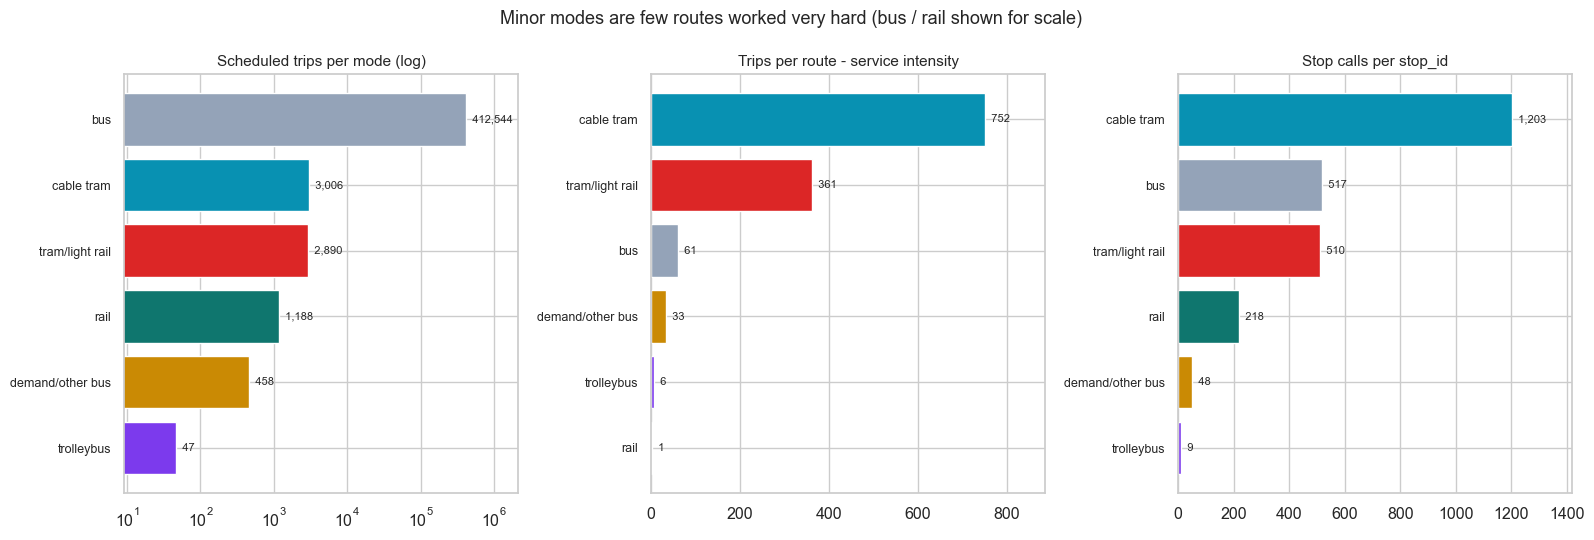

,route_type,mode_label,routes,trips,stops,stop_calls,trips_per_route,calls_per_stop,stops_per_route,is_minor_mode
3,5,cable tram,4,3006,9,10830,751.5,1203.3,2.2,True
0,0,tram/light rail,8,2890,138,70333,361.2,509.7,17.2,True
2,3,bus,6796,412544,30170,15608376,60.7,517.3,4.4,False
5,715,demand/other bus,14,458,153,7390,32.7,48.3,10.9,True
4,8,trolleybus,8,47,10,94,5.9,9.4,1.2,True
1,2,rail,962,1188,67,14601,1.2,217.9,0.1,False


In [11]:
# --- Service intensity for every mode -------------------------------------
intensity_rows = []
for rt in sorted(set(list(ALL_ROUTE_TYPES) + list(mode_calls))):
    stops_n = len(mode_stops.get(rt, ()))
    routes_n = routes_per_mode.get(rt, 0)
    trips_n = trips_per_mode.get(rt, 0)
    intensity_rows.append({
        'route_type': rt,
        'mode_label': MODE_LABELS.get(rt, f'route_type {rt}'),
        'routes': routes_n,
        'trips': trips_n,
        'stops': stops_n,
        'stop_calls': mode_calls.get(rt, 0),
        'trips_per_route': round(trips_n / routes_n, 1) if routes_n else np.nan,
        'calls_per_stop': round(mode_calls.get(rt, 0) / stops_n, 1) if stops_n else np.nan,
        'stops_per_route': round(stops_n / routes_n, 1) if routes_n else np.nan,
        'is_minor_mode': rt in MINOR_ROUTE_TYPES,
    })
intensity = pd.DataFrame(intensity_rows).sort_values('trips_per_route', ascending=False)
intensity.to_csv(TABLES / 'mode_service_intensity.csv', index=False, encoding='utf-8-sig')

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
panels = [('trips', 'Scheduled trips per mode (log)'),
          ('trips_per_route', 'Trips per route - service intensity'),
          ('calls_per_stop', 'Stop calls per stop_id')]
for ax, (col, title) in zip(axes, panels):
    d = intensity.sort_values(col, ascending=True)
    colors = [MODE_COLORS.get(rt, '#94a3b8') for rt in d['route_type']]
    bars = ax.barh(range(len(d)), d[col].to_numpy(), color=colors)
    ax.set_yticks(range(len(d)))
    ax.set_yticklabels(d['mode_label'], fontsize=9)
    ax.set_title(title, fontsize=11)
    if col == 'trips':
        ax.set_xscale('log')
    for bar, val in zip(bars, d[col].to_numpy()):
        ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2,
                f'  {val:,.0f}', va='center', fontsize=8)
    ax.margins(x=0.18)
fig.suptitle('Minor modes are few routes worked very hard (bus / rail shown for scale)', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES / 'service_intensity.png', dpi=FIG_DPI)
plt.show()

intensity

## 11. Platforms vs stations - a data artifact that changes the topology

Before measuring shape we have to be explicit about what a *node* is for these modes. In this feed a light-rail route is published as two `route_id`s (one per direction), and each direction has its **own** platform `stop_id`, with the two platforms of one physical station carrying the same `stop_name`. The cable tram, by contrast, uses a single `stop_id` per station for both directions.

The consequence is structural, not cosmetic: because the up-direction platform and the down-direction platform never appear on the same trip, there's no edge connecting them, and a single physical light-rail route appears in the graph as **two disjoint one-way corridors**. So any claim of the form "the light-rail network has N components" is partly a claim about GTFS publishing conventions.

The cell below quantifies the duplication - unique `stop_id`s vs unique `stop_name`s per mode - so that every later count is read with the right factor in mind. We deliberately **avoid** merging platforms by name: name collisions between unrelated stations elsewhere in the country make name-based merging unsafe, and the graph we analyze has to stay the same object the rest of the project uses.

In [12]:
# --- Platform duplication: stop_ids vs physical station names -------------
dup_rows = []
for rt in MINOR_ROUTE_TYPES:
    ids = set(stop_calls[rt])
    names = {ATTR.get(s, DEFAULT_ATTR)['stop_name'] for s in ids}
    with_parent = sum(1 for s in ids if ATTR.get(s, DEFAULT_ATTR)['parent_station'])
    dup_rows.append({
        'route_type': rt,
        'mode_label': MODE_LABELS[rt],
        'stop_ids': len(ids),
        'distinct_stop_names': len(names),
        'stop_ids_per_name': round(len(ids) / max(len(names), 1), 2),
        'stop_ids_with_parent_station': with_parent,
    })
platform_dup = pd.DataFrame(dup_rows)
platform_dup.to_csv(TABLES / 'platform_duplication.csv', index=False, encoding='utf-8-sig')

for r in platform_dup.itertuples():
    verdict = ('directional platforms are separate stop_ids'
               if r.stop_ids_per_name > 1.5 else 'one stop_id per physical station')
    print(f'{r.mode_label:<18} {r.stop_ids:>4} stop_ids / {r.distinct_stop_names:>4} names '
          f'= {r.stop_ids_per_name:.2f}  ->  {verdict}')
platform_dup

tram/light rail     138 stop_ids /   69 names = 2.00  ->  directional platforms are separate stop_ids
cable tram            9 stop_ids /    9 names = 1.00  ->  one stop_id per physical station
trolleybus           10 stop_ids /    8 names = 1.25  ->  one stop_id per physical station
demand/other bus    153 stop_ids /  117 names = 1.31  ->  one stop_id per physical station


,route_type,mode_label,stop_ids,distinct_stop_names,stop_ids_per_name,stop_ids_with_parent_station
0,0,tram/light rail,138,69,2.00,68
1,5,cable tram,9,9,1.00,0
2,8,trolleybus,10,8,1.25,0
3,715,demand/other bus,153,117,1.31,2


## 12. Size, shape, and redundancy of each mode graph

Now the structural characterization. For each mode we compute, exactly:

* **Size**: nodes, directed and undirected edges, number of connected components, share of the largest component, mean and maximum degree.
* **Redundancy**, via the **cyclomatic number** (circuit rank) `mu = m - n + c`, the number of independent cycles in a graph with `n` nodes, `m` undirected edges, and `c` components. `mu = 0` means the graph is a forest: **between any two stations there is exactly one path, and every internal edge is a bridge**. `mu > 0` means at least one alternative path exists somewhere. For transport networks this is the single cleanest redundancy measure.
* **Shape class** for each component, from the degree sequence:
  * `isolated` - a single node;
  * `path` - a tree with maximum degree <= 2 (a line);
  * `cycle` - every node degree 2 (a loop);
  * `star` - a tree where one node is adjacent to all the others (a hub-and-spoke terminal);
  * `tree` - acyclic, with branching but no loops;
  * `meshed` - contains at least one cycle.
* **Articulation points** and **bridges** - the exact single points of failure, using the same linear-time procedures as in notebook 03.
* **Exact betweenness** (Brandes, normalized, unweighted). Notebook 04 had to sample on the national graph; here `n` is at most a few hundred, so exact values are computed in milliseconds and there's no sampling error to caveat.
* **Service span and headway**: the first and last departure in seconds since service-day midnight (so a 25:04 departure sorts after 23:50), and the median gap between consecutive departures at the mode's busiest station - a direct read of service frequency.

The diameter is reported for the largest component only, and only when it's connected and has more than one node.

In [13]:
# --- Structural characterisation of each minor mode -----------------------
def classify_component(H):
    """Name the shape of one connected component from its degree sequence."""
    n, m = H.number_of_nodes(), H.number_of_edges()
    if n == 1:
        return 'isolated'
    degs = sorted(d for _, d in H.degree())
    acyclic = (m == n - 1)
    if acyclic:
        if degs[-1] <= 2:
            return 'path'
        if degs[-1] == n - 1:
            return 'star'
        return 'tree'
    if all(d == 2 for d in degs):
        return 'cycle'
    return 'meshed'


def headway_minutes(departure_lists):
    """Median gap between consecutive departures at the busiest stop, in minutes."""
    if not departure_lists:
        return np.nan
    busiest = max(departure_lists.values(), key=len)
    if len(busiest) < 2:
        return np.nan
    d = np.diff(np.sort(np.asarray(busiest, dtype=float)))
    d = d[d > 0]
    return round(float(np.median(d)) / 60.0, 1) if len(d) else np.nan


BETW = {}
summary_rows, component_rows = [], []
for rt in MINOR_ROUTE_TYPES:
    G, D = graphs[rt]['G'], graphs[rt]['D']
    n, m = G.number_of_nodes(), G.number_of_edges()
    comps = sorted(nx.connected_components(G), key=len, reverse=True)
    degs = np.array([d for _, d in G.degree()]) if n else np.array([0])
    ap = sorted(set(nx.articulation_points(G))) if n else []
    br = list(nx.bridges(G)) if n else []
    mu = m - n + len(comps) if n else 0
    BETW[rt] = nx.betweenness_centrality(G, normalized=True) if (n and EXACT_BETWEENNESS) else {}

    shapes = []
    for i, c in enumerate(comps):
        H = G.subgraph(c)
        shape = classify_component(H)
        shapes.append(shape)
        try:
            diam = nx.diameter(H) if len(c) > 1 else 0
        except (nx.NetworkXError, nx.NetworkXNoPath):
            diam = np.nan
        sample = sorted((G.nodes[x]['stop_name'] or x) for x in c)[:3]
        component_rows.append({
            'route_type': rt, 'mode_label': MODE_LABELS[rt], 'component_id': i,
            'nodes': len(c), 'edges': H.number_of_edges(), 'shape': shape,
            'cyclomatic_number': H.number_of_edges() - len(c) + 1,
            'diameter': diam,
            'metro': Counter(G.nodes[x]['metro'] for x in c).most_common(1)[0][0],
            'region': Counter(G.nodes[x]['region'] for x in c).most_common(1)[0][0],
            'sample_stations': ' | '.join(sample),
        })

    deps_all = [d for lst in stop_departures[rt].values() for d in lst]
    calls_total = mode_calls.get(rt, 0)
    stops_total = len(stop_calls[rt])
    summary_rows.append({
        'route_type': rt,
        'mode_label': MODE_LABELS[rt],
        'routes': routes_per_mode.get(rt, 0),
        'trips': trips_per_mode.get(rt, 0),
        'stops': stops_total,
        'graph_nodes': n,
        'directed_edges': D.number_of_edges(),
        'undirected_edges': m,
        'components': len(comps),
        'largest_component_nodes': len(comps[0]) if comps else 0,
        'largest_component_share': round(len(comps[0]) / n, 4) if n else np.nan,
        'avg_degree': round(float(degs.mean()), 2),
        'max_degree': int(degs.max()),
        'density': round(nx.density(G), 5) if n > 1 else np.nan,
        'cyclomatic_number': mu,
        'edges_per_node': round(m / n, 3) if n else np.nan,
        'articulation_points': len(ap),
        'articulation_point_share': round(len(ap) / n, 4) if n else np.nan,
        'bridges': len(br),
        'bridge_share': round(len(br) / m, 4) if m else np.nan,
        'shape_class': ', '.join(f'{v}x {k}' for k, v in Counter(shapes).most_common()),
        'diameter_largest_component': component_rows[-len(comps)]['diameter'] if comps else np.nan,
        'trips_per_route': round(trips_per_mode.get(rt, 0) / routes_per_mode.get(rt, 1), 1),
        'stop_calls': calls_total,
        'calls_per_stop': round(calls_total / stops_total, 1) if stops_total else np.nan,
        'max_calls_at_a_stop': max(stop_calls[rt].values()) if stops_total else 0,
        'first_departure': hhmm(min(deps_all)) if deps_all else '',
        'last_departure': hhmm(max(deps_all)) if deps_all else '',
        'service_span_hours': round((max(deps_all) - min(deps_all)) / 3600, 1) if deps_all else np.nan,
        'departures_after_midnight': int(sum(1 for d in deps_all if d >= 86400)),
        'median_headway_busiest_stop_minutes': headway_minutes(stop_departures[rt]),
        'max_exact_betweenness': round(max(BETW[rt].values()), 4) if BETW[rt] else np.nan,
        'exact_betweenness': bool(EXACT_BETWEENNESS),
    })

minor_summary = pd.DataFrame(summary_rows)
minor_summary.to_csv(TABLES / 'minor_modes_summary.csv', index=False, encoding='utf-8-sig')
components_df = pd.DataFrame(component_rows)
components_df.to_csv(TABLES / 'minor_mode_components.csv', index=False, encoding='utf-8-sig')

print('saved:', TABLES / 'minor_modes_summary.csv')
print('saved:', TABLES / 'minor_mode_components.csv')
display(minor_summary[['mode_label', 'graph_nodes', 'undirected_edges', 'components',
                       'avg_degree', 'max_degree', 'cyclomatic_number', 'shape_class',
                       'articulation_points', 'bridges']])
components_df

saved: C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\16_lightrail_and_minor_modes\tables\minor_modes_summary.csv
saved: C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\16_lightrail_and_minor_modes\tables\minor_mode_components.csv


,mode_label,graph_nodes,undirected_edges,components,avg_degree,max_degree,cyclomatic_number,shape_class,articulation_points,bridges
0,tram/light rail,138,134,4,1.94,3,0,"2x path, 2x tree",128,134
1,cable tram,9,7,2,1.56,2,0,2x path,5,7
2,trolleybus,8,5,3,1.25,3,0,"2x path, 1x star",1,5
3,demand/other bus,153,194,2,2.54,6,43,2x meshed,21,12


,route_type,mode_label,component_id,nodes,edges,shape,cyclomatic_number,diameter,metro,region,sample_stations
0,0,tram/light rail,0,35,34,path,0,34,Jerusalem,Jerusalem,א-סהל | בית הספר לרפואה | בית חנינא
1,0,tram/light rail,1,35,34,path,0,34,Jerusalem,Jerusalem,א-סהל | בית הספר לרפואה | בית חנינא
2,0,tram/light rail,2,34,33,tree,0,31,Tel Aviv,Center,אבא הלל | אהרונוביץ' | איסקוב
3,0,tram/light rail,3,34,33,tree,0,31,Tel Aviv,Center,אבא הלל | אהרונוביץ' | איסקוב
4,5,cable tram,0,6,5,path,0,5,Haifa,North,ביה''ח בני ציון | הדר העירייה | הנביאים
5,5,cable tram,1,3,2,path,0,2,Haifa,North,אוניברסיטת חיפה | טכניון מרכז | מרכזית המפרץ
6,8,trolleybus,0,4,3,star,0,2,Tel Aviv,Center,תחנת מוניות תל אביב מסוף רדינג | תחנת מוניות ת...
7,8,trolleybus,1,2,1,path,0,1,Tel Aviv,Center,תחנת מוניות תל אביב מסוף רדינג | תחנת מוניות ת...
8,8,trolleybus,2,2,1,path,0,1,Tel Aviv,Center,תחנת מוניות רמת גן דרך הטייסים | תחנת מוניות ת...
9,715,demand/other bus,0,129,164,meshed,36,23,Periphery,Center,'כפר הרי''ף א | אביעזר/מרכז א | אביעזר/מרכז ב


### 12a. Reading the redundancy numbers

The cell below turns the two structural columns into a sentence that means something for criticality. A mode whose cyclomatic number is zero is a **forest**: every edge is a bridge, every non-leaf node is an articulation point, and there's exactly one path between any two stations it can serve. In such a graph the question "which station is critical?" has a degenerate answer - *almost all of them* - and the only meaningful ranking is by **how much** traffic each cut leaves disconnected, which is exactly what part 16 measures.

This is the structural difference from the bus network, where notebook 03 found articulation points at only about 3% of stations.

In [14]:
# --- Redundancy verdict per mode ------------------------------------------
for r in minor_summary.itertuples():
    if r.graph_nodes == 0:
        print(f'{r.mode_label:<18} no graph (no multi-stop trips)')
        continue
    if r.cyclomatic_number == 0:
        verdict = ('FOREST - zero independent cycles: exactly one path between any two '
                   'stations, every link is a bridge')
    else:
        verdict = (f'{r.cyclomatic_number} independent cycle(s): some alternative paths exist')
    print(f'{r.mode_label:<18} n={r.graph_nodes:<4} m={r.undirected_edges:<4} '
          f'mu={r.cyclomatic_number:<3} AP={r.articulation_points} '
          f'({r.articulation_point_share:.0%} of stations)  bridges={r.bridges} '
          f'({r.bridge_share:.0%} of links)')
    print(f'{"":<18} -> {verdict}')

print()
print('For contrast, the national (mostly bus) graph in notebook 03 has articulation points')
print('at roughly 3% of its stations and bridges on under 2% of its links.')

tram/light rail    n=138  m=134  mu=0   AP=128 (93% of stations)  bridges=134 (100% of links)
                   -> FOREST - zero independent cycles: exactly one path between any two stations, every link is a bridge
cable tram         n=9    m=7    mu=0   AP=5 (56% of stations)  bridges=7 (100% of links)
                   -> FOREST - zero independent cycles: exactly one path between any two stations, every link is a bridge
trolleybus         n=8    m=5    mu=0   AP=1 (12% of stations)  bridges=5 (100% of links)
                   -> FOREST - zero independent cycles: exactly one path between any two stations, every link is a bridge
demand/other bus   n=153  m=194  mu=43  AP=21 (14% of stations)  bridges=12 (6% of links)
                   -> 43 independent cycle(s): some alternative paths exist

For contrast, the national (mostly bus) graph in notebook 03 has articulation points
at roughly 3% of its stations and bridges on under 2% of its links.


## 13. Station-level metrics, with exact betweenness

This cell writes the contract table `tables/lightrail_station_metrics.csv`. It holds **one row per station of every minor mode**, not just light rail - the `mode_label` column is what separates them, and a consumer who wants light rail only should filter on `mode_label == 'tram/light rail'`. The required columns come first and are named exactly as the data contract defines:

`stop_id, stop_name, lat, lon, degree, weighted_degree, mode_label`

`weighted_degree` is the sum of undirected edge weights at the station, i.e. **the number of scheduled services crossing the station over a service day, counting both directions** - the natural load measure for this mode.

Additional columns are appended for the analysis here and can be safely ignored: exact betweenness, stop-calls, the number of routes serving the station, the articulation-point flag, the component id, and `region`/`metro`. Stations are sorted by mode and then by exact betweenness in descending order.

In [15]:
# --- Station metrics for every minor mode ---------------------------------
station_rows = []
for rt in MINOR_ROUTE_TYPES:
    G = graphs[rt]['G']
    if G.number_of_nodes() == 0:
        continue
    comp_of = {node: i for i, c in enumerate(
        sorted(nx.connected_components(G), key=len, reverse=True)) for node in c}
    ap = set(nx.articulation_points(G))
    wdeg = dict(G.degree(weight='weight'))
    for node, data in G.nodes(data=True):
        station_rows.append({
            'stop_id': node,
            'stop_name': data.get('stop_name', ''),
            'lat': data.get('lat'),
            'lon': data.get('lon'),
            'degree': G.degree(node),
            'weighted_degree': int(wdeg.get(node, 0)),
            'mode_label': MODE_LABELS[rt],
            'route_type': rt,
            'exact_betweenness': round(BETW[rt].get(node, 0.0), 6),
            'stop_calls': int(stop_calls[rt].get(node, 0)),
            'n_routes': len(stop_routes[rt].get(node, ())),
            'is_articulation_point': node in ap,
            'component_id': comp_of.get(node, -1),
            'region': data.get('region', ''),
            'metro': data.get('metro', ''),
        })

station_metrics = (pd.DataFrame(station_rows)
                   .sort_values(['route_type', 'exact_betweenness', 'weighted_degree'],
                                ascending=[True, False, False])
                   .reset_index(drop=True))
station_metrics.to_csv(TABLES / 'lightrail_station_metrics.csv', index=False, encoding='utf-8-sig')
print('saved:', TABLES / 'lightrail_station_metrics.csv',
      f'({len(station_metrics):,} stations across {station_metrics["mode_label"].nunique()} modes)')

missing_coords = station_metrics[['lat', 'lon']].isna().any(axis=1).sum()
print('stations with missing coordinates:', int(missing_coords))

print('\nTop light-rail stations by exact betweenness:')
display(station_metrics[station_metrics['route_type'] == 0]
        .head(TOP_N)[['stop_name', 'metro', 'degree', 'weighted_degree',
                      'exact_betweenness', 'stop_calls', 'is_articulation_point']])
print('Busiest stations of every minor mode (by services crossing the station):')
station_metrics.sort_values('weighted_degree', ascending=False).head(TOP_N)[
    ['mode_label', 'stop_name', 'metro', 'degree', 'weighted_degree', 'stop_calls']]

saved: C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\16_lightrail_and_minor_modes\tables\lightrail_station_metrics.csv (308 stations across 4 modes)
stations with missing coordinates: 0

Top light-rail stations by exact betweenness:


,stop_name,metro,degree,weighted_degree,exact_betweenness,stop_calls,is_articulation_point
0,יפו - מרכז,Jerusalem,2,500,0.031022,250,True
1,יפו - מרכז,Jerusalem,2,464,0.031022,232,True
2,העירייה,Jerusalem,2,500,0.030915,250,True
3,הדווידקה,Jerusalem,2,500,0.030915,250,True
4,הדווידקה,Jerusalem,2,464,0.030915,232,True
5,העירייה,Jerusalem,2,464,0.030915,232,True
6,שער שכם,Jerusalem,2,500,0.030593,250,True
7,מחנה יהודה,Jerusalem,2,500,0.030593,250,True
8,מחנה יהודה,Jerusalem,2,464,0.030593,232,True
9,שער שכם,Jerusalem,2,464,0.030593,232,True


Busiest stations of every minor mode (by services crossing the station):


,mode_label,stop_name,metro,degree,weighted_degree,stop_calls
142,cable tram,טכניון מרכז,Haifa,2,4804,2402
34,tram/light rail,ארלוזורוב,Tel Aviv,2,2436,1218
22,tram/light rail,יהודית,Tel Aviv,2,2436,1218
42,tram/light rail,אבא הלל,Tel Aviv,2,2436,1218
55,tram/light rail,אהרונוביץ',Tel Aviv,3,2436,1218
54,tram/light rail,בן גוריון,Tel Aviv,2,2436,1218
19,tram/light rail,קרליבך,Tel Aviv,2,2436,1218
26,tram/light rail,שאול המלך,Tel Aviv,2,2436,1218
18,tram/light rail,אלנבי,Tel Aviv,2,2436,1218
46,tram/light rail,ביאליק,Tel Aviv,2,2436,1218


## 14. The geography of each mode

Four panels, one per mode, each drawing the actual edges as line segments between station coordinates, and the stations as points sized by the number of services crossing them. This is a plain lon/lat scatter and not a projected map, so each panel's aspect ratio is set to `1 / cos(mean latitude)` to keep distances roughly accurate.

The panels answer the geographic half of the question: where do these modes actually exist? The short answer visible in the graphs is that each of them is a *single metropolitan artifact* - light rail in Jerusalem and Tel Aviv, cable tram in Haifa, shared taxis inside Tel Aviv, and the demand-responsive services in rural clusters (the Judean lowlands and the Eilot area in the far south). None of them is a national network, and that's exactly why the national aggregates don't see them.

Stations without usable coordinates are excluded and counted; the test is for a finite value, so a coordinate of exactly `0.0` is kept while `NaN` is dropped.

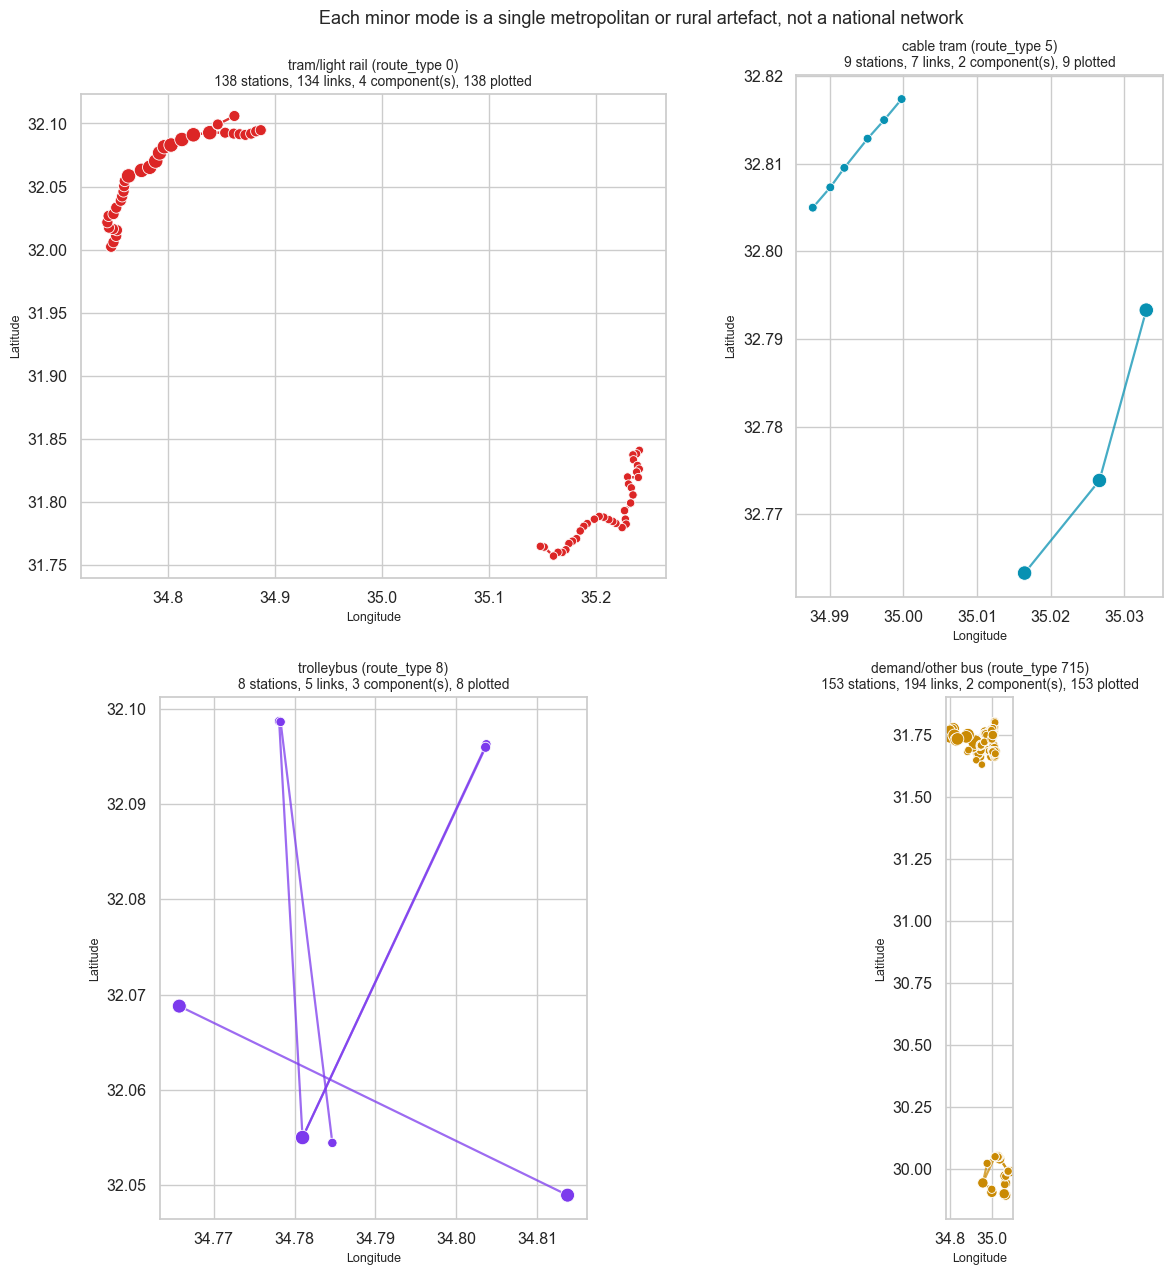

In [16]:
# --- One geographic panel per mode ----------------------------------------
def has_coords(data):
    """True only when both coordinates are present and finite (0.0 included)."""
    lat, lon = data.get('lat'), data.get('lon')
    return (lat is not None and lon is not None
            and np.isfinite(lat) and np.isfinite(lon))


def draw_mode(ax, rt, label_stations=False, max_labels=MAX_LABELLED_STATIONS, nodes=None):
    """Draw one mode's graph on `ax`; returns the number of stations plotted."""
    G = graphs[rt]['G']
    sub = G.subgraph(nodes) if nodes is not None else G
    pts = {n: (d['lon'], d['lat']) for n, d in sub.nodes(data=True) if has_coords(d)}
    if not pts:
        ax.set_axis_off()
        ax.set_title(f'{MODE_LABELS[rt]} - no usable coordinates')
        return 0
    for u, v, d in sub.edges(data=True):
        if u in pts and v in pts:
            ax.plot([pts[u][0], pts[v][0]], [pts[u][1], pts[v][1]],
                    color=MODE_COLORS.get(rt, '#475569'), linewidth=1.6, alpha=0.75, zorder=1)
    load = np.array([stop_calls[rt].get(n, 0) for n in pts], dtype=float)
    sizes = 18 + 90 * (load / load.max()) if load.max() > 0 else np.full(len(pts), 25.0)
    xs = [p[0] for p in pts.values()]
    ys = [p[1] for p in pts.values()]
    ax.scatter(xs, ys, s=sizes, c=MODE_COLORS.get(rt, '#475569'),
               edgecolors='white', linewidths=0.6, zorder=2)
    if label_stations and len(pts) <= max_labels:
        placed = set()
        for n, (x, y) in pts.items():
            name = sub.nodes[n].get('stop_name', '') or n
            if name in placed:          # both directional platforms carry the same name
                continue
            placed.add(name)
            ax.annotate(name, (x, y), fontsize=7, xytext=(3, 3),
                        textcoords='offset points', zorder=3)
    ax.set_aspect(1 / np.cos(np.deg2rad(float(np.mean(ys)))))
    ax.set_xlabel('Longitude', fontsize=9)
    ax.set_ylabel('Latitude', fontsize=9)
    return len(pts)


fig, axes = plt.subplots(2, 2, figsize=(13, 13))
for ax, rt in zip(axes.ravel(), MINOR_ROUTE_TYPES):
    plotted = draw_mode(ax, rt)
    row = minor_summary.loc[minor_summary['route_type'] == rt].iloc[0]
    ax.set_title(f'{MODE_LABELS[rt]} (route_type {rt})\n'
                 f'{row.graph_nodes} stations, {row.undirected_edges} links, '
                 f'{row.components} component(s), {plotted} plotted', fontsize=10)
fig.suptitle('Each minor mode is a single metropolitan or rural artefact, not a national network',
             fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES / 'mode_network_maps.png', dpi=FIG_DPI)
plt.show()

### 14a. The light-rail lines, with station names

Light rail is small enough to label in full, which makes the corridor structure readable: each route is a chain of stations from one terminal to another, with at most one short branch. The two panels split the light-rail graph by metropolitan area (`metro`), because the Jerusalem and Tel Aviv systems are completely separate networks that share only a `route_type`. Doubled directional platforms are labeled once per name, following part 11.

The same treatment is given to the cable tram, whose two components - the "Carmelit" funicular and the Haifa cable car - are among the shortest "networks" you can draw.

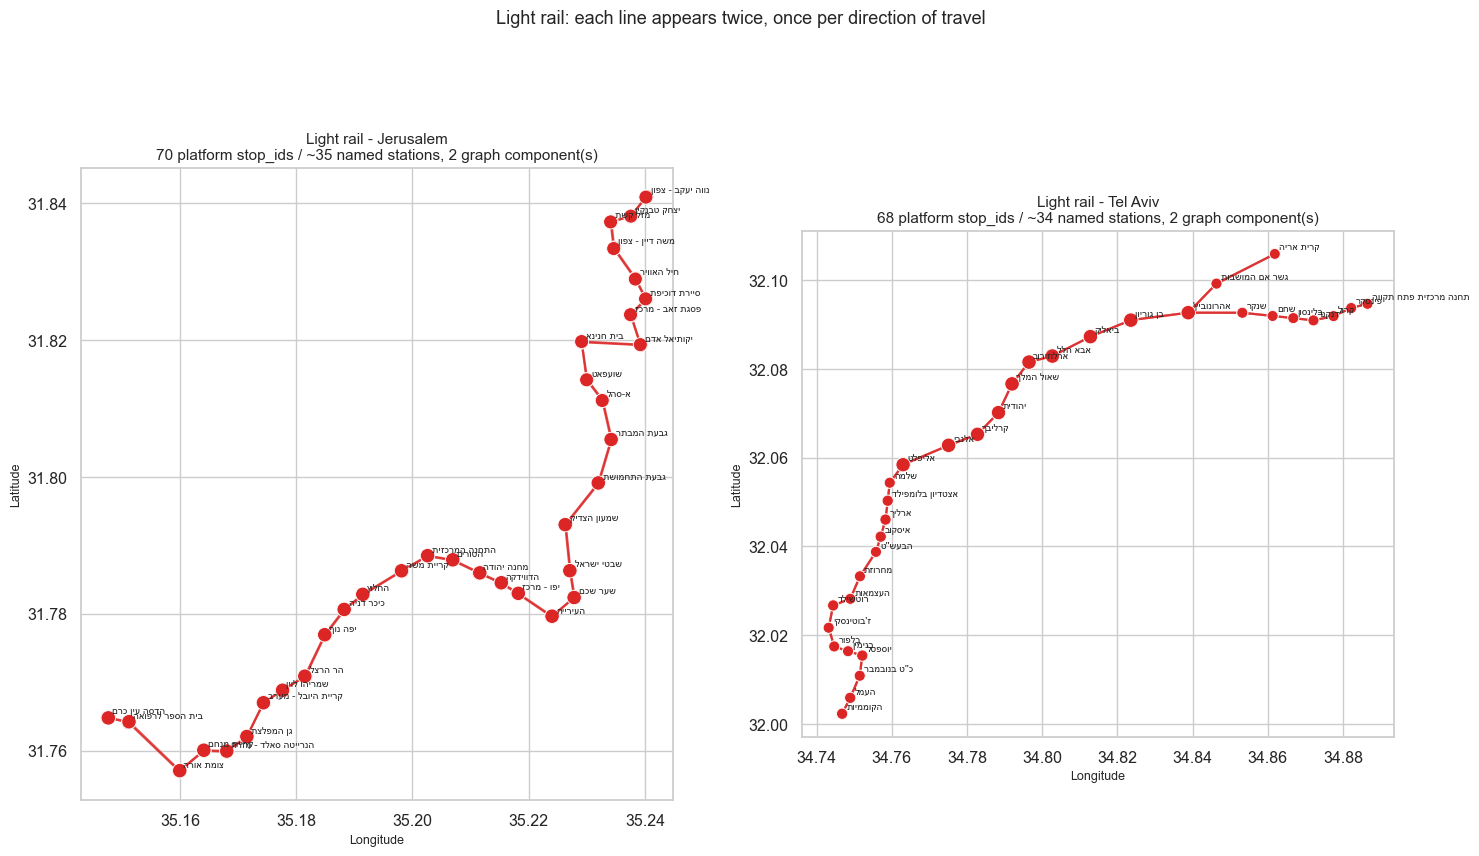

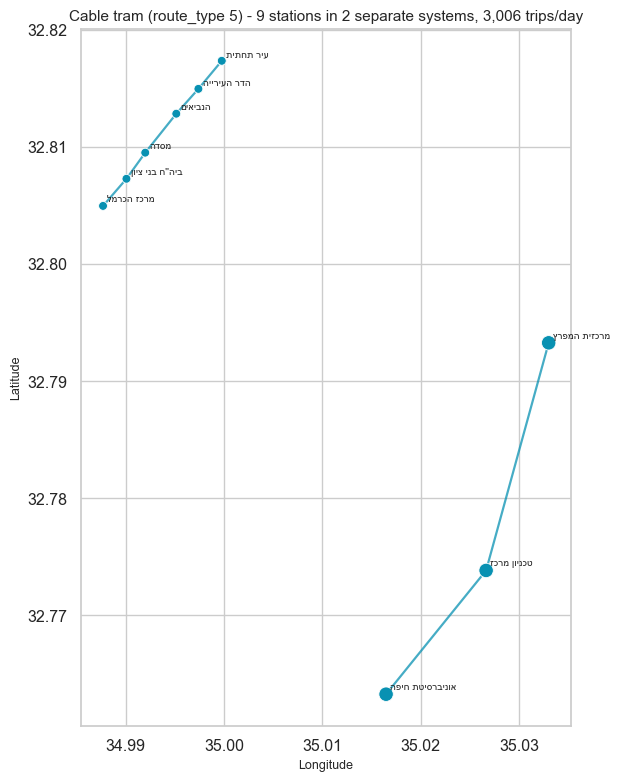

In [17]:
# --- Labelled maps: light rail by metro, then cable tram ------------------
G0 = graphs[0]['G']
groups = defaultdict(list)
for n, d in G0.nodes(data=True):
    groups[d.get('metro') or d.get('region') or 'unknown'].append(n)
groups = dict(sorted(groups.items(), key=lambda kv: -len(kv[1])))

if groups:
    fig, axes = plt.subplots(1, len(groups), figsize=(7.5 * len(groups), 9.5))
    axes = np.atleast_1d(axes)
    for ax, (metro, nodes) in zip(axes, groups.items()):
        plotted = draw_mode(ax, 0, label_stations=True, nodes=nodes)
        sub = G0.subgraph(nodes)
        ncomp = nx.number_connected_components(sub)
        names = len({sub.nodes[n]['stop_name'] for n in nodes})
        ax.set_title(f'Light rail - {metro}\n{len(nodes)} platform stop_ids / ~{names} named '
                     f'stations, {ncomp} graph component(s)', fontsize=11)
    fig.suptitle('Light rail: each line appears twice, once per direction of travel', fontsize=13)
    plt.tight_layout()
    plt.savefig(FIGURES / 'lightrail_labeled_map.png', dpi=FIG_DPI)
    plt.show()

fig, ax = plt.subplots(figsize=(7.5, 8))
draw_mode(ax, 5, label_stations=True)
row5 = minor_summary.loc[minor_summary['route_type'] == 5].iloc[0]
ax.set_title(f'Cable tram (route_type 5) - {row5.graph_nodes} stations in '
             f'{row5.components} separate systems, {row5.trips:,} trips/day', fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES / 'cabletram_labeled_map.png', dpi=FIG_DPI)
plt.show()

## 15. Exact betweenness across each mode

Betweenness centrality counts the shortest paths passing through a station. In a path graph it has a characteristic parabolic profile - the middle station sits on the most source-destination pairs, and the terminals on none - and any deviation from that parabola marks a junction or a branch.

These values are **exact** (Brandes, normalized, unweighted), not the `k`-sampled approximation notebook 04 had to use on the 30k-node national graph, and there's no sampling caveat attached to them. The plot shows the sorted betweenness profile for each mode, and the top stations are shown in a table. The absolute orderings aren't comparable to the national numbers, because betweenness is normalized within each graph separately: a station can be the most central object in the Carmelit and still be nationally negligible.

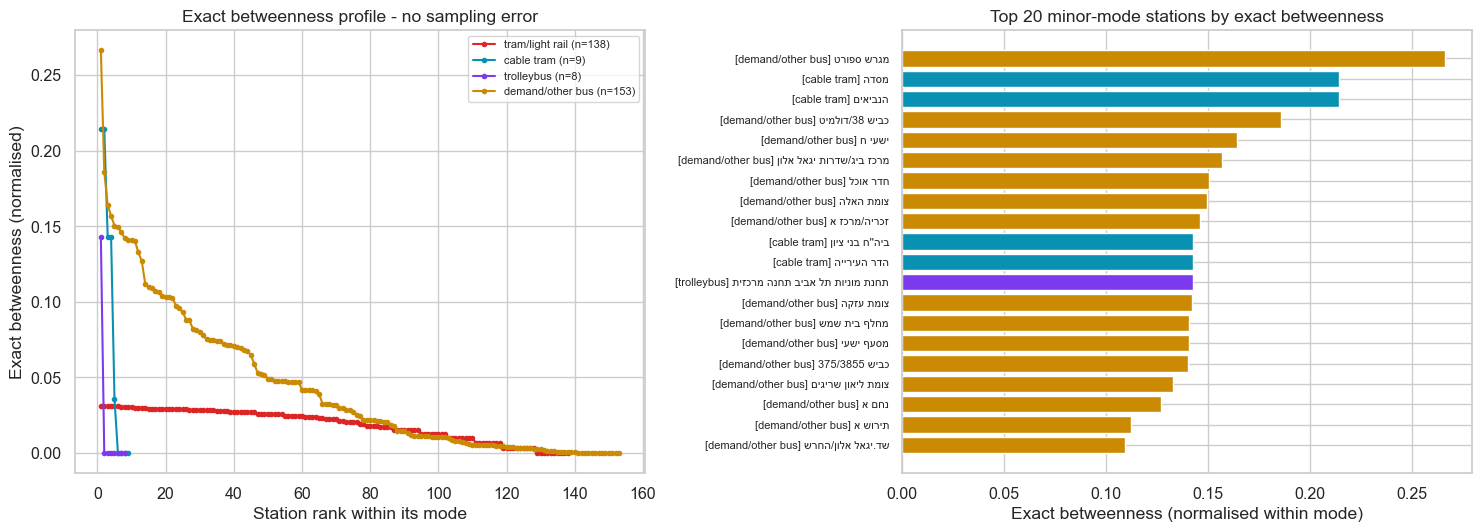

,mode_label,stop_name,metro,degree,weighted_degree,exact_betweenness,is_articulation_point
155,demand/other bus,מגרש ספורט,Periphery,5,218,0.266439,True
139,cable tram,מסדה,Haifa,2,1208,0.214286,True
138,cable tram,הנביאים,Haifa,2,1208,0.214286,True
156,demand/other bus,כביש 38/דולמיט,Periphery,6,142,0.186037,False
157,demand/other bus,ישעי ח,Periphery,3,96,0.164216,False
158,demand/other bus,מרכז ביג/שדרות יגאל אלון,Periphery,3,96,0.156882,False
159,demand/other bus,חדר אוכל,Periphery,4,86,0.150472,False
160,demand/other bus,צומת האלה,Periphery,3,88,0.149711,False
161,demand/other bus,זכריה/מרכז א,Periphery,3,96,0.146140,False
141,cable tram,ביה''ח בני ציון,Haifa,2,1208,0.142857,True


In [18]:
# --- Exact betweenness profiles -------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

for rt in MINOR_ROUTE_TYPES:
    vals = sorted(BETW[rt].values(), reverse=True)
    if not vals:
        continue
    axes[0].plot(range(1, len(vals) + 1), vals, marker='o', markersize=3,
                 color=MODE_COLORS.get(rt), label=f'{MODE_LABELS[rt]} (n={len(vals)})')
axes[0].set_xlabel('Station rank within its mode')
axes[0].set_ylabel('Exact betweenness (normalised)')
axes[0].set_title('Exact betweenness profile - no sampling error')
axes[0].legend(fontsize=8)

top_bt = (station_metrics.sort_values('exact_betweenness', ascending=False)
          .head(TOP_N).iloc[::-1])
axes[1].barh(range(len(top_bt)),
             top_bt['exact_betweenness'].to_numpy(),
             color=[MODE_COLORS.get(rt, '#475569') for rt in top_bt['route_type']])
axes[1].set_yticks(range(len(top_bt)))
axes[1].set_yticklabels([f'{r.stop_name} [{r.mode_label}]' for r in top_bt.itertuples()],
                        fontsize=8)
axes[1].set_xlabel('Exact betweenness (normalised within mode)')
axes[1].set_title(f'Top {TOP_N} minor-mode stations by exact betweenness')
plt.tight_layout()
plt.savefig(FIGURES / 'exact_betweenness.png', dpi=FIG_DPI)
plt.show()

station_metrics.sort_values('exact_betweenness', ascending=False).head(TOP_N)[
    ['mode_label', 'stop_name', 'metro', 'degree', 'weighted_degree',
     'exact_betweenness', 'is_articulation_point']]

## 16. Exact damage from removing a single station

On graphs this small we don't need a sampled attack simulation: we can remove **every** station in turn and measure the exact result. Two measures are recorded per station:

* `largest_component_share_surviving` - the size of the largest surviving component over `n - 1`. In a path graph, removing a station near the middle immediately halves this.
* `pairs_disconnected_share` - the fraction of station pairs that could reach each other before the removal (excluding pairs involving the removed station itself) and can no longer. This is the cleaner damage measure because it isn't sensitive to which side of the cut is larger. The baseline correctly excludes the removed node: if it sat in a component of size `k`, then `k - 1` pairs vanish by definition and aren't counted as damage.

The cost is `O(n)` connectivity scans per mode - a few hundred operations in total. Note what this measures and what it doesn't: it's *topological* isolation within a single transport mode. It says nothing about a rider's ability to transfer to a bus, which is a multi-modal question that notebook 17 handles - and as part 17 shows, one the feed answers pessimistically, since light-rail stations share no `stop_id` with any bus station.

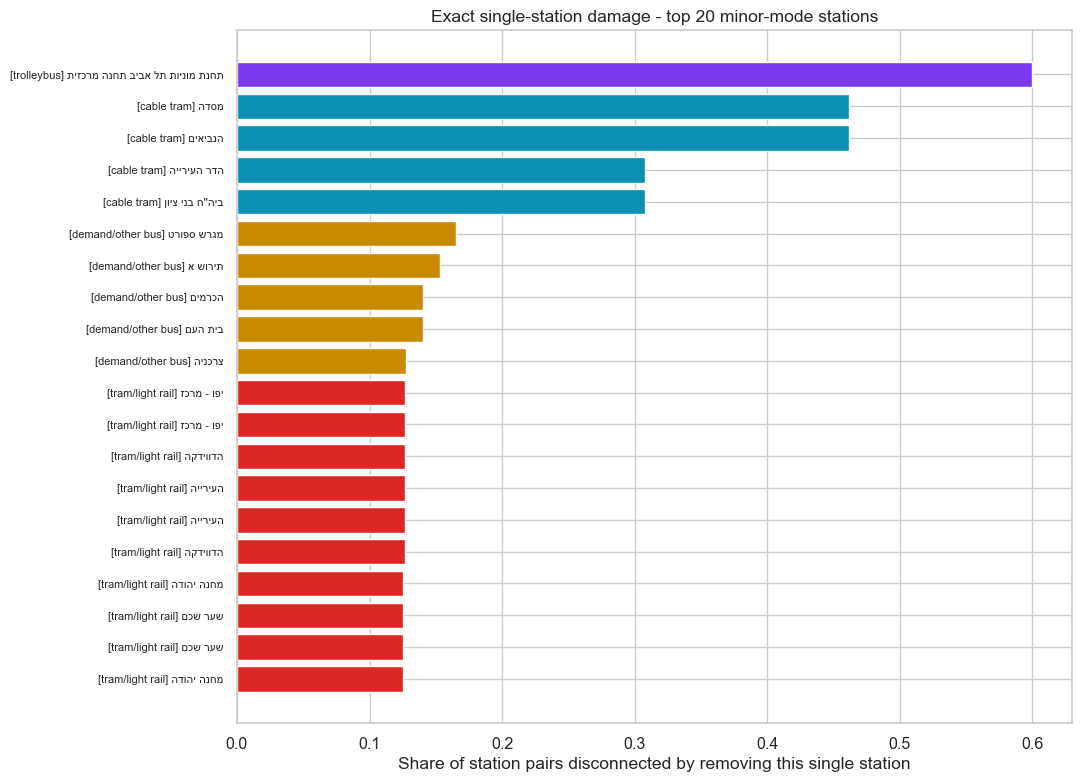

Mean share of pairs disconnected by removing one station, per mode:
                   mean    max  count
mode_label                           
cable tram        0.178  0.462      9
demand/other bus  0.007  0.166    153
tram/light rail   0.078  0.127    138
trolleybus        0.075  0.600      8


In [19]:
# --- Remove every station in turn (exact, no sampling) --------------------
def single_station_damage(G):
    """Exact damage caused by removing each node once."""
    comps = list(nx.connected_components(G))
    size_of = {n: len(c) for c in comps for n in c}
    base_pairs = sum(len(c) * (len(c) - 1) // 2 for c in comps)
    n = G.number_of_nodes()
    out = []
    for node in G.nodes():
        H = G.copy()
        H.remove_node(node)
        after = list(nx.connected_components(H))
        pairs_after = sum(len(c) * (len(c) - 1) // 2 for c in after)
        # pairs that existed among the OTHER nodes before the removal
        baseline = base_pairs - (size_of[node] - 1)
        largest = max((len(c) for c in after), default=0)
        out.append({
            'stop_id': node,
            'largest_component_share_surviving': round(largest / (n - 1), 4) if n > 1 else np.nan,
            'pairs_disconnected_share': round(1 - pairs_after / baseline, 4) if baseline else 0.0,
            'components_after': len(after),
        })
    return pd.DataFrame(out)


damage_frames = []
for rt in MINOR_ROUTE_TYPES:
    G = graphs[rt]['G']
    if G.number_of_nodes() < 2:
        continue
    d = single_station_damage(G)
    d['route_type'] = rt
    d['mode_label'] = MODE_LABELS[rt]
    damage_frames.append(d)

damage = pd.concat(damage_frames, ignore_index=True)
damage = damage.merge(
    station_metrics[['stop_id', 'route_type', 'stop_name', 'metro', 'degree',
                     'weighted_degree', 'exact_betweenness', 'is_articulation_point']],
    on=['stop_id', 'route_type'], how='left')
damage = damage.sort_values(['route_type', 'pairs_disconnected_share'],
                            ascending=[True, False]).reset_index(drop=True)
damage.to_csv(TABLES / 'minor_mode_single_station_damage.csv', index=False, encoding='utf-8-sig')

fig, ax = plt.subplots(figsize=(11, 8))
top_dmg = damage.sort_values('pairs_disconnected_share', ascending=False).head(TOP_N).iloc[::-1]
ax.barh(range(len(top_dmg)), top_dmg['pairs_disconnected_share'].to_numpy(),
        color=[MODE_COLORS.get(rt, '#475569') for rt in top_dmg['route_type']])
ax.set_yticks(range(len(top_dmg)))
ax.set_yticklabels([f'{r.stop_name} [{r.mode_label}]' for r in top_dmg.itertuples()], fontsize=8)
ax.set_xlabel('Share of station pairs disconnected by removing this single station')
ax.set_title(f'Exact single-station damage - top {TOP_N} minor-mode stations')
plt.tight_layout()
plt.savefig(FIGURES / 'single_station_damage.png', dpi=FIG_DPI)
plt.show()

print('Mean share of pairs disconnected by removing one station, per mode:')
print(damage.groupby('mode_label')['pairs_disconnected_share']
      .agg(['mean', 'max', 'count']).round(3).to_string())

## 17. Where do the minor modes sit inside the national graph?

An optional but illuminating cross-check, run only if notebook 02 produced `nodes.csv` and `edges.csv`. Notebook 03 reported that the national graph isn't fully connected: about a dozen components, one of which holds about 99.3% of the stations. This cell asks **what the other components are** by tagging each national component with the modes serving its stations.

The expected answer - and in this feed, the actual one - is that the small components are exactly the minor modes plus rail. Light-rail, cable-tram, and shared-taxi stations share **no** `stop_id` with any bus station, so in a graph whose nodes are `stop_id`s they can't touch the bus network at all: a rider moving from tram to bus walks between two stations the model treats as unconnected. The demand-responsive services are the exception - most of their stations are ordinary bus stops, so they get absorbed into the giant component.

Two consequences worth stating explicitly. First, the "fragmentation" of the national network reported in notebook 03 is mostly an effect of *coding* separate station ids, not evidence of a disconnected transport system. Second, this notebook's damage numbers are a lower bound on real-world robustness and an upper bound on modal connectivity: within a transport mode they're exact, but no transfer between modes is represented in the model anywhere.

In [20]:
# --- Optional: locate the minor modes in the national graph ---------------
if nodes_path is None or edges_path is None:
    print('notebook 02 artifacts not found - national placement cross-check skipped '
          '(run 02_graph_construction to enable it).')
else:
    nat_edges = pd.read_csv(edges_path, dtype={'from_stop': str, 'to_stop': str},
                            encoding='utf-8-sig')
    NAT = nx.from_pandas_edgelist(nat_edges, 'from_stop', 'to_stop')
    nat_comps = sorted(nx.connected_components(NAT), key=len, reverse=True)

    stop_to_modes = defaultdict(set)
    for rt, stops in mode_stops.items():
        for s in stops:
            stop_to_modes[s].add(rt)

    rows = []
    for i, c in enumerate(nat_comps):
        counts = Counter()
        for s in c:
            for rt in stop_to_modes.get(s, ()):
                counts[rt] += 1
        rows.append({
            'component_rank': i,
            'nodes': len(c),
            'modes_present': ', '.join(f'{MODE_LABELS.get(rt, rt)}:{v}'
                                       for rt, v in counts.most_common()),
            'dominant_mode': MODE_LABELS.get(counts.most_common(1)[0][0], '?') if counts else '?',
            'sample_station': sorted(ATTR.get(s, DEFAULT_ATTR)['stop_name'] for s in c)[0],
        })
    nat_comp_df = pd.DataFrame(rows)
    nat_comp_df.to_csv(TABLES / 'national_component_modes.csv', index=False, encoding='utf-8-sig')

    print(f'national graph: {NAT.number_of_nodes():,} nodes, {len(nat_comps)} components')
    display(nat_comp_df)

    # How many stops of each minor mode are shared with another mode at all?
    print('Stops shared with at least one other mode (same stop_id):')
    for rt in MINOR_ROUTE_TYPES:
        stops = mode_stops.get(rt, set())
        shared = sum(1 for s in stops if len(stop_to_modes[s]) > 1)
        print(f'  {MODE_LABELS[rt]:<18} {shared:>4} / {len(stops):<4} '
              f'({shared / max(len(stops), 1):.0%}) - '
              f'{"integrated with the bus network" if shared else "no shared stop_id with any other mode"}')

national graph: 30,463 nodes, 12 components


,component_rank,nodes,modes_present,dominant_mode,sample_station
0,0,30237,"bus:30165, demand/other bus:153",bus,מסעף נווה מונסון/כביש 412
1,1,67,rail:67,rail,אופקים
2,2,35,tram/light rail:35,tram/light rail,א-סהל
3,3,35,tram/light rail:35,tram/light rail,א-סהל
4,4,34,tram/light rail:34,tram/light rail,אבא הלל
5,5,34,tram/light rail:34,tram/light rail,אבא הלל
6,6,6,cable tram:6,cable tram,ביה''ח בני ציון
7,7,4,bus:4,bus,בית ספר ישורון/קלאוזנר
8,8,4,trolleybus:4,trolleybus,תחנת מוניות תל אביב מסוף רדינג
9,9,3,cable tram:3,cable tram,אוניברסיטת חיפה


Stops shared with at least one other mode (same stop_id):
  tram/light rail       0 / 138  (0%) - no shared stop_id with any other mode
  cable tram            0 / 9    (0%) - no shared stop_id with any other mode
  trolleybus            0 / 10   (0%) - no shared stop_id with any other mode
  demand/other bus     81 / 153  (53%) - integrated with the bus network


## 18. When do these modes actually run?

The last dimension of intensity is time. Using the seconds-since-service-day-midnight values decoded in part 7, we count departures per service hour for each mode. Hours 24, 25, ... are kept as separate buckets and not folded back to 0, 1, ... - these are late-night services of the *previous* service day, and merging them would both distort the small hours and hide the very fact that these modes run past midnight.

The profile separates true mass-transit modes from the rest: a mode with a smooth all-day profile, a long span, and a headway of a few minutes carries a metropolitan corridor; a mode with a few dozen departures concentrated in office hours is a niche service, and its "network" statistics shouldn't be over-interpreted.

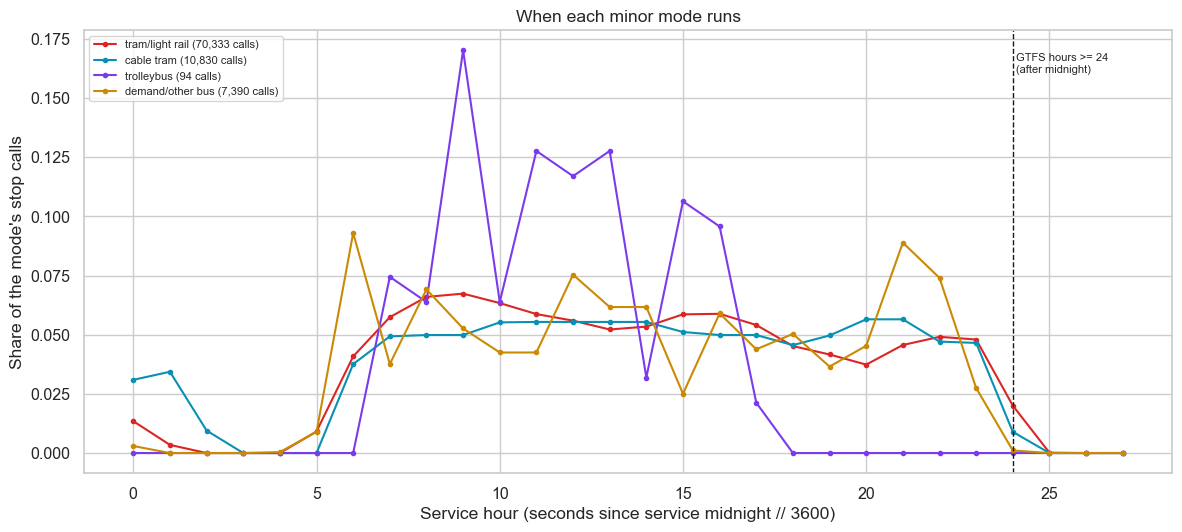

,mode_label,first_departure,last_departure,service_span_hours,departures_after_midnight,median_headway_busiest_stop_minutes,max_calls_at_a_stop
0,tram/light rail,00:00,25:04,25.1,1421,1.0,1218
1,cable tram,00:00,24:35,24.6,97,0.7,2402
2,trolleybus,07:00,17:08,10.1,0,8.0,34
3,demand/other bus,00:03,24:14,24.2,8,7.5,170


In [21]:
# --- Departures per service hour ------------------------------------------
hour_rows = []
for rt in MINOR_ROUTE_TYPES:
    deps = [d for lst in stop_departures[rt].values() for d in lst]
    counts = Counter(d // 3600 for d in deps)
    for h in range(0, 28):
        hour_rows.append({'route_type': rt, 'mode_label': MODE_LABELS[rt],
                          'service_hour': h, 'departures': counts.get(h, 0)})
hourly = pd.DataFrame(hour_rows)
hourly.to_csv(TABLES / 'hourly_departures.csv', index=False, encoding='utf-8-sig')

fig, ax = plt.subplots(figsize=(12, 5.5))
for rt in MINOR_ROUTE_TYPES:
    d = hourly[hourly['route_type'] == rt]
    total = d['departures'].sum()
    if total == 0:
        continue
    ax.plot(d['service_hour'], d['departures'] / total, marker='o', markersize=3,
            color=MODE_COLORS.get(rt), label=f'{MODE_LABELS[rt]} ({total:,} calls)')
ax.axvline(24, color='#111827', linestyle='--', linewidth=1)
ax.text(24.1, ax.get_ylim()[1] * 0.9, 'GTFS hours >= 24\n(after midnight)', fontsize=8)
ax.set_xlabel('Service hour (seconds since service midnight // 3600)')
ax.set_ylabel('Share of the mode\'s stop calls')
ax.set_title('When each minor mode runs')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES / 'hourly_departures.png', dpi=FIG_DPI)
plt.show()

minor_summary[['mode_label', 'first_departure', 'last_departure', 'service_span_hours',
               'departures_after_midnight', 'median_headway_busiest_stop_minutes',
               'max_calls_at_a_stop']]

## 19. Saving the stage summary

The headline numbers are gathered into `lightrail_summary.json` (this stage's contract artifact), the four graphs are pickled as `{mode_label: networkx.Graph}` so a later notebook can reuse them without re-streaming the 816 MB feed, and every file written by this notebook is listed with its size as a final check that nothing landed outside the stage folder.

In [22]:
# --- Stage summary and artifacts ------------------------------------------
lr = minor_summary.loc[minor_summary['route_type'] == 0].iloc[0]
bus_row = intensity.loc[intensity['route_type'] == 3]
bus_tpr = float(bus_row['trips_per_route'].iloc[0]) if len(bus_row) else None

summary = {
    'modes_analysed': {str(rt): MODE_LABELS[rt] for rt in MINOR_ROUTE_TYPES},
    'exact_centrality': bool(EXACT_BETWEENNESS),
    'stream_stats': stream_stats,
    'lightrail': {
        'routes': int(lr.routes), 'trips': int(lr.trips),
        'stop_ids': int(lr.graph_nodes),
        'distinct_station_names': int(platform_dup.loc[
            platform_dup['route_type'] == 0, 'distinct_stop_names'].iloc[0]),
        'undirected_edges': int(lr.undirected_edges),
        'components': int(lr.components),
        'cyclomatic_number': int(lr.cyclomatic_number),
        'articulation_points': int(lr.articulation_points),
        'articulation_point_share': float(lr.articulation_point_share),
        'bridges': int(lr.bridges),
        'trips_per_route': float(lr.trips_per_route),
        'max_calls_at_a_stop': int(lr.max_calls_at_a_stop),
        'median_headway_busiest_stop_minutes': (
            None if pd.isna(lr.median_headway_busiest_stop_minutes)
            else float(lr.median_headway_busiest_stop_minutes)),
        'service_span_hours': float(lr.service_span_hours),
        'shape_class': lr.shape_class,
    },
    'bus_trips_per_route_baseline': bus_tpr,
    'per_mode': {
        MODE_LABELS[rt]: {
            k: (None if pd.isna(v) else (v.item() if hasattr(v, 'item') else v))
            for k, v in minor_summary.loc[
                minor_summary['route_type'] == rt].iloc[0].to_dict().items()
        }
        for rt in MINOR_ROUTE_TYPES
    },
    'caveats': [
        'route_type 8 is labelled trolleybus in GTFS but is operated by shared-taxi companies.',
        'Light-rail directional platforms are separate stop_ids, so each line appears as two '
        'one-way components; component counts are partly a publishing convention.',
        'Weights are scheduled trips, not passengers - GTFS carries no ridership data.',
        'Damage measures are within-mode only; no modal substitution is represented.',
    ],
}
with open(STAGE / 'lightrail_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2, default=str)

with open(STAGE / 'lightrail_graphs.pkl', 'wb') as f:
    pickle.dump({MODE_LABELS[rt]: graphs[rt]['G'] for rt in MINOR_ROUTE_TYPES}, f)

print('Artifacts written under', STAGE)
for p in sorted(STAGE.rglob('*')):
    if p.is_file():
        print(f'  {p.relative_to(STAGE)}  ({p.stat().st_size / 1024:,.1f} KB)')

Artifacts written under C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\16_lightrail_and_minor_modes
  figures\cabletram_labeled_map.png  (61.2 KB)
  figures\exact_betweenness.png  (160.3 KB)
  figures\hourly_departures.png  (160.1 KB)
  figures\lightrail_labeled_map.png  (200.2 KB)
  figures\mode_network_maps.png  (225.5 KB)
  figures\service_intensity.png  (70.6 KB)
  figures\single_station_damage.png  (89.4 KB)
  lightrail_graphs.pkl  (32.0 KB)
  lightrail_summary.json  (5.6 KB)
  tables\hourly_departures.csv  (2.6 KB)
  tables\lightrail_station_metrics.csv  (34.1 KB)
  tables\minor_mode_components.csv  (1.6 KB)
  tables\minor_mode_routes.csv  (4.8 KB)
  tables\minor_mode_single_station_damage.csv  (27.8 KB)
  tables\minor_modes_summary.csv  (1.1 KB)
  tables\mode_service_intensity.csv  (0.4 KB)
  tables\national_component_modes.csv  (0.8 KB)
  tables\platform_duplication.csv  (0.2 KB)


## Conclusions

*(The numbers below are the ones printed by the cells above on this snapshot of the feed; re-run to refresh them.)*

* **The minor modes are 0.8% of the routes and 1.5% of the trips, but they aren't minor in intensity.** The cable tram runs about 752 trips per route and light rail about 361, against about 61 for buses and about 1.2 for rail. Measured per route, these are the most heavily used services in the country: a single light-rail platform in Tel Aviv sees over 1,200 scheduled stop calls over a service day, meaning a tram roughly every 70 seconds across the operating span, and the Haifa cable-car stations see about 2,400 stop calls each.
* **These are corridors, not networks.** The light-rail graph is a **forest** - cyclomatic number 0 - so *every* edge is a bridge and about 93% of its stations are articulation points; the cable tram is likewise two disjoint paths. Compare the national numbers from notebook 03: about 3% of stations are articulation points and under 2% of edges are bridges. This is the notebook's structural point: on a path there's no alternative path by construction, so the redundancy that lets the bus network absorb failures simply isn't here.
* **So criticality has to be measured by *how much* is left disconnected, not by *whether* anything is.** The exact single-station removals in part 16 show damage rising gradually toward the middle of each corridor - removing a station in the middle of a line disconnects about half of all station pairs on that line - while terminal stations cost almost nothing. Combined with the load figures, the mid-corridor light-rail stations are the single points of failure with the most severe consequences in the whole minor-mode set: high traffic, zero redundancy.
* **The only minor mode that's genuinely meshed is the demand-responsive service (route_type 715).** It has 153 stations, about 194 edges, and a cyclomatic number of about 43 - a real meshed network with alternative paths - because different variants of a trip on the same rural route take different roads. This is an artifact of how flexible routing is published, not evidence of a physically redundant system, and shouldn't be read as "rural service is more robust".
* **Two labeling problems are substantive and shouldn't be ignored.** (1) `route_type = 8` is "trolleybus" in the GTFS spec but is operated here by taxi companies - 8 routes, 47 trips, and each trip has exactly two stop calls, so its "graph" is three disconnected stubs with no interior. No network conclusion should be drawn from it. (2) Every light-rail route is published as two directional `route_id`s with **separate platform `stop_id`s**, which is why 138 light-rail stop_ids correspond to only about 69 named stations, and why the model shows 4 components instead of 2 lines. Every per-`stop_id` figure for light rail should be read with this factor of two in mind.
* **The minor modes are exactly the fragmentation the national analysis reported.** Every small component of the national graph, apart from rail and one stray bus cluster, is a minor mode: light rail, cable tram, and shared taxis share no `stop_id` with any bus station, so in a stop-id-based model they can't touch the bus network. Notebook 03's "about a dozen components" is therefore mostly a coding effect, and any multi-modal transfer analysis (notebook 17) has to be based on spatial proximity rather than shared ids, or it will wrongly conclude there are no transfer points at all.
* **Limitations, honestly.** The weights are scheduled trips, never riders - GTFS has no ridership data, so "load" here means *supply*. Damage is measured within a single transport mode, so a light-rail failure that a parallel bus line would have absorbed is still counted as a full disconnection. The feed is a single snapshot: only the light-rail lines running in it appear, and lines that opened later don't exist in these numbers. Finally, betweenness is normalized within each mode graph separately, so a value of 0.2 in the Carmelit and a value of 0.2 at the national level are not the same magnitude and shouldn't be compared across tables.